# CheXpert Multi-Label Chest X-Ray Classification

End-to-end pipeline using **PyTorch** and **DenseNet-121**: data loading, patient-level
splitting, training, and evaluation (including the official CheXpert `valid.csv` set).

**Contents:**
1. Environment setup
2. Configuration
3. Dataset loading & label statistics
4. Patient-level train/val/test split
5. Uncertainty-label handling strategy
6. PyTorch `Dataset` / `DataLoader` + a visual sanity check
7. DenseNet-121 model definition
8. Training loop with early stopping and checkpointing
9. Training artifacts (config, dataset statistics, seed record)
10. Training curves
11. Load the best checkpoint for evaluation
12. Generate & save predictions (local test, local val, official CheXpert valid)
13. Evaluation metrics (AUROC, PR-AUC, F1, Recall, Precision, Specificity, Brier score)
14. Threshold selection (validation set)
15. Evaluate the local test set and the official CheXpert valid set
16. ROC / Precision-Recall curves, confusion matrices, calibration
17. Grad-CAM
18. Final results summary & output verification
19. Final interpretation


## 1. Environment Setup

Install any missing packages, import everything the notebook needs, detect
Python/PyTorch/CUDA info, and fix random seeds so results are reproducible.
Every `import` and `pip install` in the notebook lives in this section.

In [1]:
# --- Install packages that are commonly missing on Kaggle/Colab (safe to re-run) ---
# We only install if an import fails, to avoid unnecessary pip calls.
import importlib
import subprocess
import sys


def ensure_package(import_name, pip_name=None):
    pip_name = pip_name or import_name
    try:
        importlib.import_module(import_name)
    except ImportError:
        print(f"Installing missing package: {pip_name}")
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pip_name])


for import_name, pip_name in [
    ("sklearn", "scikit-learn"),
    ("pandas", "pandas"),
    ("PIL", "Pillow"),
    ("tqdm", "tqdm"),
    ("matplotlib", "matplotlib"),
    ("seaborn", "seaborn"),
    ("pytorch_grad_cam", "grad-cam"),
]:
    ensure_package(import_name, pip_name)

print("Package check complete.")


Installing missing package: grad-cam
Package check complete.


In [2]:
import os
import json
import time
import random
import platform
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from tqdm.auto import tqdm

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
import torchvision.models as models

from sklearn.metrics import (
    roc_auc_score,
    roc_curve,
    average_precision_score,
    precision_recall_curve,
    f1_score,
    precision_score,
    recall_score,
    confusion_matrix,
    brier_score_loss,
)
from sklearn.calibration import calibration_curve

from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image

print("=" * 60)
print("ENVIRONMENT INFO")
print("=" * 60)
print(f"Python version : {platform.python_version()}")
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available : {torch.cuda.is_available()}")

if torch.cuda.is_available():
    device = torch.device("cuda")
    gpu_name = torch.cuda.get_device_name(0)
    total_mem_gb = torch.cuda.get_device_properties(0).total_memory / (1024 ** 3)
    print(f"GPU name       : {gpu_name}")
    print(f"GPU memory     : {total_mem_gb:.1f} GB (total)")
else:
    device = torch.device("cpu")
    print("No GPU detected. Training will run on CPU (this will be SLOW for DenseNet-121).")
    print("On Kaggle: enable a GPU accelerator (Settings > Accelerator > GPU).")
    print("On Colab: Runtime > Change runtime type > GPU.")

print("=" * 60)


ENVIRONMENT INFO
Python version : 3.13.15
PyTorch version: 2.11.0+cu128
CUDA available : True
GPU name       : Tesla T4
GPU memory     : 14.6 GB (total)


In [3]:
# --- Reproducibility ---
RANDOM_SEED = 42


def set_seed(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    # These two lines trade a bit of speed for determinism. For a "reasonably
    # simple" project we keep them on; disable if you need max throughput.
    torch.backends.cudnn.deterministic = False
    torch.backends.cudnn.benchmark = True


set_seed(RANDOM_SEED)
print(f"Random seed set to {RANDOM_SEED}")


Random seed set to 42


In [4]:
from google.colab import drive

drive.mount("/content/drive")


Mounted at /content/drive


In [5]:
archive = "/content/drive/MyDrive/CheXpert/1.archive"
extract_dir = "/content/CheXpert"

os.makedirs(extract_dir, exist_ok=True)

!unzip -q "$archive" -d "$extract_dir"


## 2. Configuration

Everything you are likely to want to change lives in this one `CONFIG` dict. **Edit `DATA_DIR` to point at your copy of CheXpert.**

Expected structure (standard CheXpert-v1.0-small layout, as used on Kaggle):

```
DATA_DIR/
├── train.csv
├── valid.csv
├── train/
│   └── patientXXXXX/studyY/viewZ_frontal.jpg
└── valid/
    └── patientXXXXX/studyY/viewZ_frontal.jpg
```

The `Path` column inside `train.csv` / `valid.csv` is usually already relative (e.g. `CheXpert-v1.0-small/train/patient00001/study1/view1_frontal.jpg`), so we join it against a `DATASET_ROOT` that is the *parent* of that `CheXpert-v1.0-small` folder. We handle both "path already includes the CheXpert-v1.0-small prefix" and "path is relative to DATA_DIR directly" cases below, since this varies between Kaggle mirrors.

In [6]:
CONFIG = {
    # ---- Paths (EDIT THESE) ----
    "DATA_DIR": "/content/CheXpert",  # <-- change this to your dataset root
    "OUTPUT_DIR": "/content/drive/MyDrive/CheXpert/model_artifacts",

    # ---- Data ----
    "TRAIN_CSV_NAME": "train.csv",
    "VALID_CSV_NAME": "valid.csv",   # official CheXpert "valid" split (small, ~200 studies)
    "IMAGE_SIZE": 224,
    "BATCH_SIZE": 64,
    "NUM_WORKERS": 2,
    "PIN_MEMORY": True,

    # ---- Split ----
    "VAL_FRACTION": 0.10,   # of TRAIN patients, held out for validation (see Section 4)
    "TEST_FRACTION": 0.10,  # of TRAIN patients, held out for a local test set

    # ---- Uncertainty handling (see Section 5) ----
    # "ignore"      -> uncertain labels excluded from loss via per-label masking
    # "zeros"       -> u -> 0 (U-Zeros from the CheXpert paper)
    # "ones"        -> u -> 1 (U-Ones from the CheXpert paper)
    # "ones_zeros_per_pathology" -> the best-performing per-pathology mapping reported
    #                  in the CheXpert paper for 5 key pathologies, "zeros" for the rest
    "UNCERTAINTY_STRATEGY": "ones_zeros_per_pathology",

    # ---- Model / training ----
    "MODEL_NAME": "densenet121",
    "PRETRAINED": True,
    "LEARNING_RATE": 1e-4,
    "WEIGHT_DECAY": 1e-5,
    "NUM_EPOCHS": 15,
    "EARLY_STOPPING_PATIENCE": 2,   # epochs without val AUROC improvement before stopping
    "LR_SCHEDULER_PATIENCE": 1,     # ReduceLROnPlateau patience
    "USE_POS_WEIGHT": True,         # counteract class imbalance in BCEWithLogitsLoss

    "RANDOM_SEED": RANDOM_SEED,
}

PATHOLOGIES = [
    "No Finding",
    "Enlarged Cardiomediastinum",
    "Cardiomegaly",
    "Lung Lesion",
    "Lung Opacity",
    "Edema",
    "Consolidation",
    "Pneumonia",
    "Atelectasis",
    "Pneumothorax",
    "Pleural Effusion",
    "Pleural Other",
    "Fracture",
    "Support Devices",
]
NUM_CLASSES = len(PATHOLOGIES)
print(f"Tracking {NUM_CLASSES} pathologies.")

DATA_DIR = Path(CONFIG["DATA_DIR"])
OUTPUT_DIR = Path(CONFIG["OUTPUT_DIR"])


Tracking 14 pathologies.


In [7]:
# --- Create the output folder structure up front ---
SUBDIRS = ["checkpoints", "logs", "plots", "predictions", "metrics", "gradcam", "config"]

for sub in SUBDIRS:
    (OUTPUT_DIR / sub).mkdir(parents=True, exist_ok=True)

print("Created output directories:")
for sub in SUBDIRS:
    print(f"  {OUTPUT_DIR / sub}")

# Save the config immediately so it's captured even if training is interrupted later.
with open(OUTPUT_DIR / "config" / "config.json", "w") as f:
    json.dump(CONFIG, f, indent=2)
print(f"\nSaved config to {OUTPUT_DIR / 'config' / 'config.json'}")


Created output directories:
  /content/drive/MyDrive/CheXpert/model_artifacts/checkpoints
  /content/drive/MyDrive/CheXpert/model_artifacts/logs
  /content/drive/MyDrive/CheXpert/model_artifacts/plots
  /content/drive/MyDrive/CheXpert/model_artifacts/predictions
  /content/drive/MyDrive/CheXpert/model_artifacts/metrics
  /content/drive/MyDrive/CheXpert/model_artifacts/gradcam
  /content/drive/MyDrive/CheXpert/model_artifacts/config

Saved config to /content/drive/MyDrive/CheXpert/model_artifacts/config/config.json


## 3. Dataset Loading

We load the official CheXpert CSVs (`train.csv`, `valid.csv`), resolve image paths against `DATA_DIR`, and verify the files actually exist on disk before doing anything else. This catches path-configuration mistakes early instead of failing deep inside training.

CheXpert label encoding in the raw CSVs:
* `1.0` → positive
* `0.0` → negative
* `-1.0` → uncertain
* *(blank / NaN)* → missing / not mentioned

We keep this raw `-1 / 0 / 1 / NaN` encoding in `df_raw` and only apply the uncertainty strategy later (Section 5), so nothing is silently thrown away at load time.

In [8]:
def resolve_image_path(data_dir: Path, csv_path: str) -> Path:
    """Resolve a CheXpert CSV 'Path' entry against DATA_DIR.

    Handles both common layouts:
      1) csv path already starts with 'CheXpert-v1.0-small/...' and DATA_DIR
         is the folder that CONTAINS 'CheXpert-v1.0-small/'.
      2) csv path starts with 'CheXpert-v1.0-small/...' but DATA_DIR
         itself already IS the 'CheXpert-v1.0-small' folder (common on Kaggle),
         in which case we strip the redundant prefix.
    """
    csv_path = csv_path.strip()
    direct = data_dir / csv_path
    if direct.exists():
        return direct

    # Try stripping a leading 'CheXpert-v1.0-small/' if DATA_DIR already is that folder
    prefix = "CheXpert-v1.0-small/"
    if csv_path.startswith(prefix):
        stripped = data_dir / csv_path[len(prefix):]
        if stripped.exists():
            return stripped

    # Fall back to the direct join even if it doesn't exist yet; caller checks existence.
    return direct


def load_chexpert_csv(data_dir: Path, csv_name: str) -> pd.DataFrame:
    csv_path = data_dir / csv_name
    if not csv_path.exists():
        raise FileNotFoundError(
            f"Could not find {csv_path}. Check CONFIG['DATA_DIR'] and CONFIG['TRAIN_CSV_NAME']/"
            f"['VALID_CSV_NAME']."
        )
    df = pd.read_csv(csv_path)
    df["resolved_path"] = df["Path"].apply(lambda p: str(resolve_image_path(data_dir, p)))

    # Patient / study IDs are embedded in the path, e.g. .../patient00001/study1/view1_frontal.jpg
    df["patient_id"] = df["Path"].str.extract(r"(patient\d+)")
    df["study_id"] = df["Path"].str.extract(r"(study\d+)")
    return df


print(f"Loading CSVs from: {DATA_DIR}")
df_train_raw = load_chexpert_csv(DATA_DIR, CONFIG["TRAIN_CSV_NAME"])
df_valid_raw = load_chexpert_csv(DATA_DIR, CONFIG["VALID_CSV_NAME"])

print(f"train.csv rows: {len(df_train_raw):,}")
print(f"valid.csv rows: {len(df_valid_raw):,}")


Loading CSVs from: /content/CheXpert
train.csv rows: 223,414
valid.csv rows: 234


In [9]:
# --- Verify a sample of image paths actually exist (checking every row can be slow
#     for 200k+ images, so we check a random sample + fail loudly if the sample is bad) ---
def check_paths_exist(df: pd.DataFrame, sample_size: int = 500, seed: int = RANDOM_SEED):
    sample = df.sample(n=min(sample_size, len(df)), random_state=seed)
    exists = sample["resolved_path"].apply(lambda p: Path(p).exists())
    frac_exist = exists.mean()
    print(f"  Checked {len(sample)} sampled images: {exists.sum()}/{len(sample)} exist "
          f"({frac_exist:.1%}).")
    if frac_exist < 0.99:
        missing_example = sample.loc[~exists, "resolved_path"].iloc[0] if (~exists).any() else None
        print("  WARNING: many sampled image files were not found on disk.")
        print(f"  Example missing path: {missing_example}")
        print("  -> Double check CONFIG['DATA_DIR'] points at the correct dataset root.")
    return frac_exist

print("Checking train image paths...")
check_paths_exist(df_train_raw)
print("Checking valid image paths...")
check_paths_exist(df_valid_raw)


Checking train image paths...
  Checked 500 sampled images: 500/500 exist (100.0%).
Checking valid image paths...
  Checked 234 sampled images: 234/234 exist (100.0%).


np.float64(1.0)

In [10]:
# --- Build a clean dataframe: image path, patient ID, study ID, and the 14 labels ---
KEEP_COLS = ["resolved_path", "patient_id", "study_id"] + PATHOLOGIES

def build_clean_df(df_raw: pd.DataFrame) -> pd.DataFrame:
    missing_cols = [c for c in PATHOLOGIES if c not in df_raw.columns]
    if missing_cols:
        raise ValueError(f"CSV is missing expected pathology columns: {missing_cols}")
    clean = df_raw[KEEP_COLS].copy()
    clean = clean.rename(columns={"resolved_path": "image_path"})
    return clean

df_train_clean = build_clean_df(df_train_raw)
df_valid_official = build_clean_df(df_valid_raw)  # official CheXpert "valid" split, kept separate

print(f"Clean train dataframe: {df_train_clean.shape}")
print(f"Clean official-valid dataframe: {df_valid_official.shape}")
df_train_clean.head()


Clean train dataframe: (223414, 17)
Clean official-valid dataframe: (234, 17)


,image_path,patient_id,study_id,No Finding,Enlarged Cardiomediastinum,Cardiomegaly,Lung Lesion,Lung Opacity,Edema,Consolidation,Pneumonia,Atelectasis,Pneumothorax,Pleural Effusion,Pleural Other,Fracture,Support Devices
0,/content/CheXpert/train/patient00001/study1/vi...,patient00001,study1,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,1.0
1,/content/CheXpert/train/patient00002/study2/vi...,patient00002,study2,NaN,NaN,-1.0,NaN,1.0,-1.0,-1.0,NaN,-1.0,NaN,-1.0,NaN,1.0,NaN
2,/content/CheXpert/train/patient00002/study1/vi...,patient00002,study1,NaN,NaN,NaN,NaN,1.0,NaN,-1.0,NaN,NaN,NaN,NaN,NaN,1.0,NaN
3,/content/CheXpert/train/patient00002/study1/vi...,patient00002,study1,NaN,NaN,NaN,NaN,1.0,NaN,-1.0,NaN,NaN,NaN,NaN,NaN,1.0,NaN
4,/content/CheXpert/train/patient00003/study1/vi...,patient00003,study1,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN


### 3.1 Dataset statistics

Counts of patients/studies/images and the raw label distribution (positive / negative / uncertain / missing) across all 14 observations, computed on `train.csv` (the large split we'll further divide ourselves in Section 4).

In [11]:
n_patients = df_train_clean["patient_id"].nunique()
n_studies = df_train_clean.groupby("patient_id")["study_id"].apply(lambda s: len(set(s))).sum()
n_images = len(df_train_clean)

label_values = df_train_clean[PATHOLOGIES].values.flatten()
n_positive = int(np.sum(label_values == 1.0))
n_negative = int(np.sum(label_values == 0.0))
n_uncertain = int(np.sum(label_values == -1.0))
n_missing = int(pd.isna(label_values).sum())

print("=" * 60)
print("DATASET STATISTICS (train.csv)")
print("=" * 60)
print(f"Patients          : {n_patients:,}")
print(f"Studies (approx.) : {n_studies:,}")
print(f"Images            : {n_images:,}")
print("-" * 60)
print(f"Total label cells : {len(label_values):,}  (= {n_images:,} images x {NUM_CLASSES} labels)")
print(f"  Positive  (1)   : {n_positive:,} ({n_positive/len(label_values):.1%})")
print(f"  Negative  (0)   : {n_negative:,} ({n_negative/len(label_values):.1%})")
print(f"  Uncertain (-1)  : {n_uncertain:,} ({n_uncertain/len(label_values):.1%})")
print(f"  Missing (blank) : {n_missing:,} ({n_missing/len(label_values):.1%})")
print("=" * 60)


DATASET STATISTICS (train.csv)
Patients          : 64,540
Studies (approx.) : 187,641
Images            : 223,414
------------------------------------------------------------
Total label cells : 3,127,796  (= 223,414 images x 14 labels)
  Positive  (1)   : 515,589 (16.5%)
  Negative  (0)   : 194,275 (6.2%)
  Uncertain (-1)  : 139,958 (4.5%)
  Missing (blank) : 2,277,974 (72.8%)


In [12]:
# --- Per-pathology label distribution ---
def label_distribution(df: pd.DataFrame) -> pd.DataFrame:
    rows = []
    for p in PATHOLOGIES:
        col = df[p]
        rows.append({
            "pathology": p,
            "positive": int((col == 1.0).sum()),
            "negative": int((col == 0.0).sum()),
            "uncertain": int((col == -1.0).sum()),
            "missing": int(col.isna().sum()),
        })
    dist = pd.DataFrame(rows).set_index("pathology")
    dist["positive_pct"] = (dist["positive"] / len(df) * 100).round(1)
    dist["uncertain_pct"] = (dist["uncertain"] / len(df) * 100).round(1)
    return dist

dist_df = label_distribution(df_train_clean)
dist_df


,positive,negative,uncertain,missing,positive_pct,uncertain_pct
pathology,,,,,,
No Finding,22381,0,0,201033,10.0,0.0
Enlarged Cardiomediastinum,10798,21638,12403,178575,4.8,5.6
Cardiomegaly,27000,11116,8087,177211,12.1,3.6
Lung Lesion,9186,1270,1488,211470,4.1,0.7
Lung Opacity,105581,6599,5598,105636,47.3,2.5
Edema,52246,20726,12984,137458,23.4,5.8
Consolidation,14783,28097,27742,152792,6.6,12.4
Pneumonia,6039,2799,18770,195806,2.7,8.4
Atelectasis,33376,1328,33739,154971,14.9,15.1


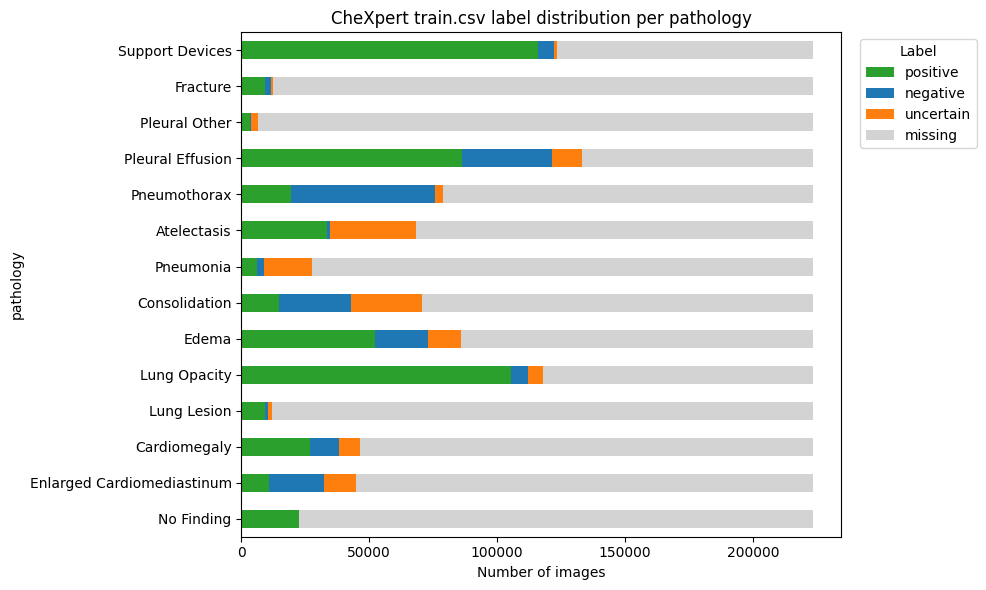

Saved label distribution plot to /content/drive/MyDrive/CheXpert/model_artifacts/plots/label_distribution.png


In [13]:
fig, ax = plt.subplots(figsize=(10, 6))
dist_plot = dist_df[["positive", "negative", "uncertain", "missing"]]
dist_plot.plot(kind="barh", stacked=True, ax=ax, color=["#2ca02c", "#1f77b4", "#ff7f0e", "#d3d3d3"])
ax.set_xlabel("Number of images")
ax.set_title("CheXpert train.csv label distribution per pathology")
ax.legend(title="Label", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plot_path = OUTPUT_DIR / "plots" / "label_distribution.png"
plt.savefig(plot_path, dpi=150)
plt.show()
print(f"Saved label distribution plot to {plot_path}")


## 4. Data Splitting (by patient)

**Why patient-level splitting matters:** a single CheXpert patient can have multiple studies and multiple images per study. If we split by *image*, images from the same patient can leak across train/val/test, letting the model "cheat" by memorizing patient-specific anatomy rather than learning generalizable disease features. So we split by unique `patient_id` first, then assign every image belonging to that patient to the same split.

**About the official CheXpert `valid.csv`:** CheXpert ships an official validation split (~200 studies, likely re-labeled by radiologists rather than the automatic labeler used for `train.csv`). We keep it loaded as `df_valid_official` and evaluate against it separately in Section 15, alongside our own held-out test set — but for day-to-day training/early-stopping/checkpointing we carve our own train/val/test split out of `train.csv`. Reasons:
* `valid.csv` only has ~200 rows, too small and noisy to drive early stopping reliably epoch-to-epoch.
* CheXpert has no public `test.csv` with labels at all (the real test set is used for the hidden leaderboard), so we need our own held-out test set to evaluate the final model.

If you'd rather train against the official valid split directly, that's a reasonable alternative — just swap `val_loader` in Section 8 for one built on `df_valid_official`.

In [14]:
def split_by_patient(df: pd.DataFrame, val_frac: float, test_frac: float, seed: int):
    patients = df["patient_id"].unique()
    rng = np.random.RandomState(seed)
    rng.shuffle(patients)

    n = len(patients)
    n_val = int(round(n * val_frac))
    n_test = int(round(n * test_frac))
    n_train = n - n_val - n_test

    train_patients = set(patients[:n_train])
    val_patients = set(patients[n_train:n_train + n_val])
    test_patients = set(patients[n_train + n_val:])

    train_df = df[df["patient_id"].isin(train_patients)].reset_index(drop=True)
    val_df = df[df["patient_id"].isin(val_patients)].reset_index(drop=True)
    test_df = df[df["patient_id"].isin(test_patients)].reset_index(drop=True)
    return train_df, val_df, test_df


df_train, df_val, df_test = split_by_patient(
    df_train_clean,
    val_frac=CONFIG["VAL_FRACTION"],
    test_frac=CONFIG["TEST_FRACTION"],
    seed=RANDOM_SEED,
)

# Sanity check: no patient overlap between splits
train_p = set(df_train["patient_id"])
val_p = set(df_val["patient_id"])
test_p = set(df_test["patient_id"])
assert not (train_p & val_p), "Patient leakage between train and val!"
assert not (train_p & test_p), "Patient leakage between train and test!"
assert not (val_p & test_p), "Patient leakage between val and test!"

print("Patient-level split (no overlap confirmed):")
print(f"  Train: {len(train_p):,} patients, {len(df_train):,} images "
      f"({len(df_train)/len(df_train_clean):.1%})")
print(f"  Val  : {len(val_p):,} patients, {len(df_val):,} images "
      f"({len(df_val)/len(df_train_clean):.1%})")
print(f"  Test : {len(test_p):,} patients, {len(df_test):,} images "
      f"({len(df_test)/len(df_train_clean):.1%})")
print(f"  (Official CheXpert valid.csv also available separately: {len(df_valid_official)} images)")


Patient-level split (no overlap confirmed):
  Train: 51,632 patients, 178,841 images (80.0%)
  Val  : 6,454 patients, 22,279 images (10.0%)
  Test : 6,454 patients, 22,294 images (10.0%)
  (Official CheXpert valid.csv also available separately: 234 images)


In [15]:
# Persist the split as an artifact, so a later run can reproduce the exact same test set.
df_train.to_csv(OUTPUT_DIR / "config" / "split_train.csv", index=False)
df_val.to_csv(OUTPUT_DIR / "config" / "split_val.csv", index=False)
df_test.to_csv(OUTPUT_DIR / "config" / "split_test.csv", index=False)
print("Saved split CSVs to outputs/config/ (split_train.csv, split_val.csv, split_test.csv)")


Saved split CSVs to outputs/config/ (split_train.csv, split_val.csv, split_test.csv)


## 5. Handling Label Uncertainty

The CheXpert paper (Irvin et al., 2019) found that roughly a third of labels involve the uncertain (`u` / `-1`) flag, and that **no single strategy was best for every pathology** — different mappings worked better for different observations, and the paper's best-performing model used a *per-pathology mix* of strategies. We do not claim the strategy below is optimal; it's a documented, configurable default, and switching it is a one-line change to `CONFIG["UNCERTAINTY_STRATEGY"]`.

We implement four strategies rather than a full 3-class-per-pathology model, because a genuine multi-class-per-label architecture (3 x 14 output logits, 3-class cross-entropy per pathology, careful loss balancing) adds real complexity for a "keep it understandable" project. That said, all the strategies below are one function (`encode_labels`), so a future extension to full 3-class-per-pathology is a contained change if you want to explore it later — the mapping approach is called "U-Ignore" / "U-Zeros" / "U-Ones" in the paper, so this is a well-precedented simplification, not something invented for this notebook.

**Available strategies** (set via `CONFIG["UNCERTAINTY_STRATEGY"]`):

| Strategy | What happens to `-1` (uncertain) | What happens to missing | Trade-off |
|---|---|---|---|
| `"ignore"` (U-Ignore) | Excluded from the loss for that image/label via a mask | Excluded from the loss | Cleanest signal, but the model never even sees uncertain examples, and some pathologies get very few remaining labels |
| `"zeros"` (U-Zeros) | Mapped to `0` (negative) | Excluded from the loss | Simple; may bias the model toward under-predicting truly-uncertain-but-actually-positive cases |
| `"ones"` (U-Ones) | Mapped to `1` (positive) | Excluded from the loss | Simple; may bias the model toward over-predicting |
| `"ones_zeros_per_pathology"` **(default)** | Per-pathology: `1` for {Atelectasis, Edema, Pleural Effusion}, `0` for {Cardiomegaly, Consolidation}, `0` for all remaining pathologies | Excluded from the loss | Mirrors the *specific* per-pathology assignment the CheXpert paper reports as its best U-Ones/U-Zeros combination for those 5 headline pathologies; the remaining 9 pathologies default to U-Zeros since the paper doesn't report a clearly-better alternative for them |

In every strategy, **missing** (blank) labels are always excluded from the loss via a per-label mask — they are genuinely "not mentioned," not negative, and CheXpert's paper treats them the same way (a label mask matching only the labels the radiologist/labeler actually assigned).

Missing labels are never silently coerced to `0`; the `label_mask` tensor produced below is what actually zeroes out their contribution to `BCEWithLogitsLoss` in Section 7.

In [16]:
# Pathologies where the CheXpert paper reports U-Ones performing best
U_ONES_PATHOLOGIES = {"Atelectasis", "Edema", "Pleural Effusion"}
# Pathologies where the CheXpert paper reports U-Zeros performing best
U_ZEROS_PATHOLOGIES = {"Cardiomegaly", "Consolidation"}


def encode_labels(raw_labels: np.ndarray, pathologies: list, strategy: str):
    """Convert raw CheXpert labels {1.0, 0.0, -1.0, NaN} into:
      - `targets`: float array, uncertain/missing filled with a placeholder (0.0) that
         will be masked out of the loss wherever `mask` is 0.
      - `mask`: float array, 1.0 where the label should count toward the loss, 0.0 where
         it should be ignored (always true for missing; conditionally true for uncertain).
    """
    raw_labels = raw_labels.astype(float)
    targets = np.zeros_like(raw_labels)
    mask = np.ones_like(raw_labels)

    for i, path in enumerate(pathologies):
        col = raw_labels[:, i] if raw_labels.ndim == 2 else np.array([raw_labels[i]])
        is_missing = np.isnan(col)
        is_uncertain = col == -1.0
        is_negative = col == 0.0
        is_positive = col == 1.0

        # Missing is always excluded from the loss.
        mask_col = mask[:, i] if mask.ndim == 2 else mask
        tgt_col = targets[:, i] if targets.ndim == 2 else targets
        mask_col[is_missing] = 0.0

        tgt_col[is_negative] = 0.0
        tgt_col[is_positive] = 1.0

        if strategy == "ignore":
            mask_col[is_uncertain] = 0.0
        elif strategy == "zeros":
            tgt_col[is_uncertain] = 0.0
        elif strategy == "ones":
            tgt_col[is_uncertain] = 1.0
        elif strategy == "ones_zeros_per_pathology":
            if path in U_ONES_PATHOLOGIES:
                tgt_col[is_uncertain] = 1.0
            elif path == "Pneumonia":
                mask_col[is_uncertain] = 0.0
            else:
                # Includes U_ZEROS_PATHOLOGIES and the remaining default-to-zero pathologies.
                tgt_col[is_uncertain] = 0.0
        else:
            raise ValueError(f"Unknown UNCERTAINTY_STRATEGY: {strategy}")

    return targets, mask


# Quick self-check on a tiny synthetic example
_test_raw = np.array([[1.0, 0.0, -1.0, np.nan]])
_test_targets, _test_mask = encode_labels(_test_raw, ["Atelectasis"] * 4, "ones_zeros_per_pathology")
print("Sanity check (targets):", _test_targets)
print("Sanity check (mask)   :", _test_mask)
assert _test_mask[0, 3] == 0.0, "Missing label should always be masked out"
print("encode_labels() sanity check passed.")


Sanity check (targets): [[1. 0. 1. 0.]]
Sanity check (mask)   : [[1. 1. 1. 0.]]
encode_labels() sanity check passed.


## 6. Image Preprocessing, PyTorch `Dataset`, and `DataLoader`s

Preprocessing:
* Resize to `IMAGE_SIZE x IMAGE_SIZE`
* Convert grayscale chest X-rays to 3-channel (DenseNet-121 expects 3 input channels)
* ImageNet normalization, since we use ImageNet-pretrained weights
* Modest training-time augmentation only: small rotations, small affine translation, and horizontal flip. We keep augmentation mild and deliberately **avoid** aggressive color/contrast jitter or vertical flips, which could distort or invert anatomically meaningful patterns in an X-ray (e.g. flipping top/bottom would put the diaphragm above the lungs).

In [17]:
IMAGE_SIZE = CONFIG["IMAGE_SIZE"]
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

train_transform = T.Compose([
    T.Grayscale(num_output_channels=3),
    T.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    T.RandomHorizontalFlip(p=0.5),          # left/right flip is anatomically plausible
    T.RandomRotation(degrees=7),             # small rotation only
    T.RandomAffine(degrees=0, translate=(0.03, 0.03)),  # tiny translation
    T.ToTensor(),
    T.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

eval_transform = T.Compose([
    T.Grayscale(num_output_channels=3),
    T.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    T.ToTensor(),
    T.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

print("Train transform:", train_transform)
print("\nEval transform:", eval_transform)


Train transform: Compose(
    Grayscale(num_output_channels=3)
    Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
    RandomHorizontalFlip(p=0.5)
    RandomRotation(degrees=[-7.0, 7.0], interpolation=nearest, expand=False, fill=0)
    RandomAffine(degrees=[0.0, 0.0], translate=(0.03, 0.03))
    ToTensor()
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
)

Eval transform: Compose(
    Grayscale(num_output_channels=3)
    Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
    ToTensor()
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
)


In [18]:
class CheXpertDataset(Dataset):
    """A minimal multi-label CheXpert dataset.

    Returns (image_tensor, target_tensor, mask_tensor, image_path).
    `mask` marks which of the 14 labels should count toward the loss for this image
    (see Section 5) -- missing labels are always masked out, uncertain labels are
    masked out only under the 'ignore' strategy.
    """

    def __init__(self, df: pd.DataFrame, pathologies: list, transform, uncertainty_strategy: str):
        self.df = df.reset_index(drop=True)
        self.pathologies = pathologies
        self.transform = transform
        self.uncertainty_strategy = uncertainty_strategy

        raw_labels = self.df[pathologies].values.astype(float)
        self.targets, self.masks = encode_labels(raw_labels, pathologies, uncertainty_strategy)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        image_path = row["image_path"]
        try:
            image = Image.open(image_path).convert("L")  # load as grayscale
        except (FileNotFoundError, OSError) as e:
            raise FileNotFoundError(
                f"Could not open image at {image_path}. Check CONFIG['DATA_DIR']."
            ) from e

        if self.transform is not None:
            image = self.transform(image)

        target = torch.from_numpy(self.targets[idx]).float()
        mask = torch.from_numpy(self.masks[idx]).float()
        return image, target, mask, image_path


train_dataset = CheXpertDataset(df_train, PATHOLOGIES, train_transform, CONFIG["UNCERTAINTY_STRATEGY"])
val_dataset = CheXpertDataset(df_val, PATHOLOGIES, eval_transform, CONFIG["UNCERTAINTY_STRATEGY"])
test_dataset = CheXpertDataset(df_test, PATHOLOGIES, eval_transform, CONFIG["UNCERTAINTY_STRATEGY"])

print(f"Train dataset: {len(train_dataset):,} images")
print(f"Val dataset  : {len(val_dataset):,} images")
print(f"Test dataset : {len(test_dataset):,} images")


Train dataset: 178,841 images
Val dataset  : 22,279 images
Test dataset : 22,294 images


In [19]:
# num_workers=0 is not compatible with persistent_workers/prefetch_factor, so only
# set them when we actually have worker processes.
loader_kwargs = dict(
    batch_size=CONFIG["BATCH_SIZE"],
    num_workers=CONFIG["NUM_WORKERS"],
    pin_memory=CONFIG["PIN_MEMORY"] and torch.cuda.is_available(),
)
if CONFIG["NUM_WORKERS"] > 0:
    loader_kwargs["persistent_workers"] = True
    loader_kwargs["prefetch_factor"] = 2

train_loader = DataLoader(train_dataset, shuffle=True, drop_last=False, **loader_kwargs)
val_loader = DataLoader(val_dataset, shuffle=False, drop_last=False, **loader_kwargs)
test_loader = DataLoader(test_dataset, shuffle=False, drop_last=False, **loader_kwargs)

print(f"Train batches: {len(train_loader)}")
print(f"Val batches  : {len(val_loader)}")
print(f"Test batches : {len(test_loader)}")


Train batches: 2795
Val batches  : 349
Test batches : 349


### 6.1 Visual sanity check

Before training, always look at a batch of real examples with their labels — this catches bugs (wrong normalization, mislabeled columns, wrong crop) far faster than debugging a training loop.

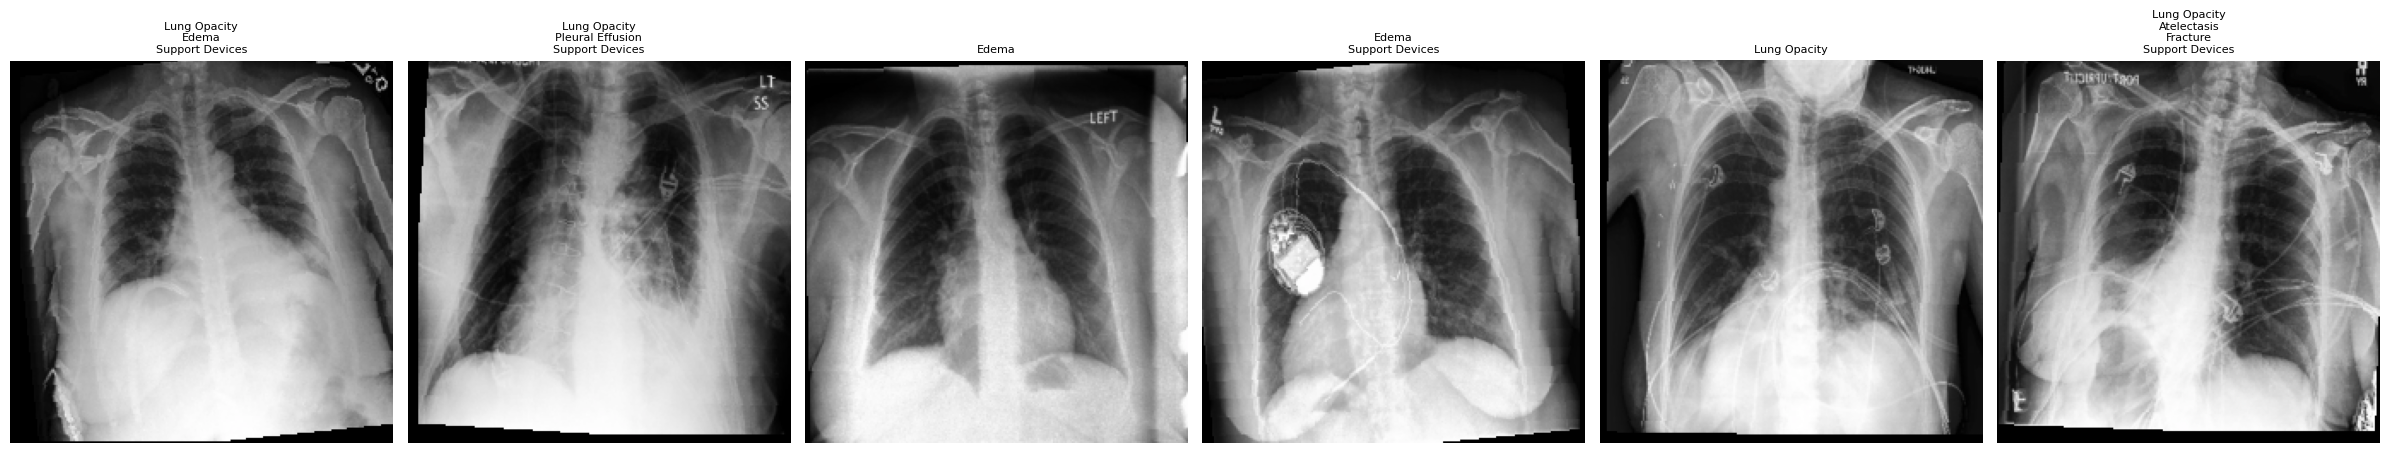

Saved sample grid to /content/drive/MyDrive/CheXpert/model_artifacts/plots/dataset_sample.png


In [20]:
def denormalize(img_tensor):
    mean = torch.tensor(IMAGENET_MEAN).view(3, 1, 1)
    std = torch.tensor(IMAGENET_STD).view(3, 1, 1)
    return (img_tensor * std + mean).clamp(0, 1)


def show_batch(dataset, n=6, seed=RANDOM_SEED):
    rng = np.random.RandomState(seed)
    indices = rng.choice(len(dataset), size=min(n, len(dataset)), replace=False)

    fig, axes = plt.subplots(1, len(indices), figsize=(4 * len(indices), 5))
    if len(indices) == 1:
        axes = [axes]

    for ax, idx in zip(axes, indices):
        image, target, mask, path = dataset[idx]
        img_np = denormalize(image).permute(1, 2, 0).numpy()
        ax.imshow(img_np)
        ax.axis("off")

        positive_labels = [PATHOLOGIES[i] for i in range(NUM_CLASSES)
                            if mask[i] == 1 and target[i] == 1]
        title = "\n".join(positive_labels) if positive_labels else "(no positive labels)"
        ax.set_title(title, fontsize=8)

    plt.tight_layout()
    sample_plot_path = OUTPUT_DIR / "plots" / "dataset_sample.png"
    plt.savefig(sample_plot_path, dpi=150)
    plt.show()
    print(f"Saved sample grid to {sample_plot_path}")

show_batch(train_dataset, n=6)


## 7. Model: DenseNet-121

We use `torchvision`'s ImageNet-pretrained DenseNet-121 and replace its final `classifier` layer with a `Linear(in_features, NUM_CLASSES)` producing 14 raw logits (one per pathology). We use `BCEWithLogitsLoss` — the standard choice for multi-label classification — combined with the `mask` tensor from Section 5/6 so that masked-out (missing, and optionally uncertain) labels contribute exactly zero gradient.

We also compute a simple `pos_weight` per class (ratio of negative-to-positive counts in the training set, capped to avoid extreme values) to counteract class imbalance, as suggested by the CheXpert paper's use of weighted loss terms — this is a standard, easy-to-understand technique rather than a custom loss function.

In [21]:
def build_model(num_classes: int, pretrained: bool = True) -> nn.Module:
    weights = models.DenseNet121_Weights.IMAGENET1K_V1 if pretrained else None
    model = models.densenet121(weights=weights)
    in_features = model.classifier.in_features
    model.classifier = nn.Linear(in_features, num_classes)
    return model


model = build_model(NUM_CLASSES, pretrained=CONFIG["PRETRAINED"])
model = model.to(device)

n_params = sum(p.numel() for p in model.parameters())
n_trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"DenseNet-121 loaded (pretrained={CONFIG['PRETRAINED']}).")
print(f"Total parameters    : {n_params:,}")
print(f"Trainable parameters: {n_trainable:,}")
print(f"Output layer        : {model.classifier}")


Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to /root/.cache/torch/hub/checkpoints/densenet121-a639ec97.pth


100%|██████████| 30.8M/30.8M [00:00<00:00, 160MB/s]


DenseNet-121 loaded (pretrained=True).
Total parameters    : 6,968,206
Trainable parameters: 6,968,206
Output layer        : Linear(in_features=1024, out_features=14, bias=True)


In [22]:
def compute_pos_weight(dataset: CheXpertDataset, cap: float = 10.0) -> torch.Tensor:
    """pos_weight[c] = (#negatives counted in loss) / (#positives counted in loss), capped.

    Only counts labels where mask == 1, so masked-out (missing/ignored-uncertain)
    entries don't distort the ratio.
    """
    targets = dataset.targets
    masks = dataset.masks
    pos_weights = np.ones(targets.shape[1], dtype=np.float32)

    for c in range(targets.shape[1]):
        valid = masks[:, c] == 1
        n_pos = (targets[valid, c] == 1).sum()
        n_neg = (targets[valid, c] == 0).sum()
        if n_pos > 0:
            w = n_neg / n_pos
            pos_weights[c] = min(w, cap)
        else:
            pos_weights[c] = 1.0  # no positive examples at all; weighting is meaningless

    return torch.tensor(pos_weights, dtype=torch.float32)


if CONFIG["USE_POS_WEIGHT"]:
    pos_weight = compute_pos_weight(train_dataset).to(device)
    print("Per-class pos_weight (negative/positive ratio, capped at 10.0):")
    for path, w in zip(PATHOLOGIES, pos_weight.tolist()):
        print(f"  {path:30s}: {w:.2f}")
else:
    pos_weight = None
    print("USE_POS_WEIGHT is False; using unweighted BCEWithLogitsLoss.")

# reduction='none' so we can apply the per-label mask ourselves before averaging
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight, reduction="none")


def masked_bce_loss(logits, targets, mask):
    """Average BCE loss over only the labels where mask == 1."""
    raw_loss = criterion(logits, targets)  # shape (batch, num_classes)
    raw_loss = raw_loss * mask
    denom = mask.sum().clamp(min=1.0)  # avoid divide-by-zero if a batch is fully masked
    return raw_loss.sum() / denom


Per-class pos_weight (negative/positive ratio, capped at 10.0):
  No Finding                    : 0.00
  Enlarged Cardiomediastinum    : 3.13
  Cardiomegaly                  : 0.71
  Lung Lesion                   : 0.30
  Lung Opacity                  : 0.12
  Edema                         : 0.32
  Consolidation                 : 3.78
  Pneumonia                     : 0.45
  Atelectasis                   : 0.02
  Pneumothorax                  : 3.06
  Pleural Effusion              : 0.36
  Pleural Other                 : 0.85
  Fracture                      : 0.34
  Support Devices               : 0.06


## 8. Training

Configuration used (see `CONFIG` in Section 2 — edit there, not here):
```
IMAGE_SIZE    = 224
BATCH_SIZE    = 64
LEARNING_RATE = 1e-4
NUM_EPOCHS    = 15
WEIGHT_DECAY  = 1e-5
```
These match the CheXpert paper / standard DenseNet-121 transfer-learning practice, but they are starting points — we cannot see your dataset size or GPU, so treat epoch count/batch size as things to revisit once you've watched the first couple of epochs run.

Training setup:
* **Optimizer:** AdamW (Adam + decoupled weight decay, generally a slightly better default than plain Adam)
* **LR scheduler:** `ReduceLROnPlateau`, watching validation AUROC, so the LR drops automatically if validation performance stalls
* **Early stopping:** stop if validation AUROC hasn't improved for `EARLY_STOPPING_PATIENCE` epochs
* **Checkpointing:** save both the *latest* model (in case of a crash) and the *best* model (by validation AUROC) every epoch
* **Metrics tracked:** training loss, validation loss, validation AUROC (macro-averaged across the 14 pathologies, skipping any pathology with only one class present in the current validation split)

In [23]:
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=CONFIG["LEARNING_RATE"],
    weight_decay=CONFIG["WEIGHT_DECAY"],
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="max", factor=0.5, patience=CONFIG["LR_SCHEDULER_PATIENCE"]
)


In [24]:
scaler = torch.amp.GradScaler("cuda", enabled=(device.type == "cuda"))


def run_epoch(model, loader, optimizer=None, device=device, desc="train"):
    """One pass over `loader`. If `optimizer` is provided, trains; otherwise evaluates.

    Returns (avg_loss, macro_auroc, per_class_auroc_dict).
    """
    is_train = optimizer is not None
    model.train() if is_train else model.eval()

    total_loss, total_batches = 0.0, 0
    all_targets, all_probs, all_masks = [], [], []

    progress = tqdm(loader, desc=desc, leave=False)
    with torch.set_grad_enabled(is_train):
        for images, targets, mask, _paths in progress:
            images = images.to(device, non_blocking=True)
            targets = targets.to(device, non_blocking=True)
            mask = mask.to(device, non_blocking=True)

            with torch.amp.autocast("cuda", enabled=(device.type == "cuda")):
                logits = model(images)
                loss = masked_bce_loss(logits, targets, mask)

            if is_train:
                optimizer.zero_grad(set_to_none=True)
                scaler.scale(loss).backward()
                scaler.step(optimizer)
                scaler.update()

            total_loss += loss.item()
            total_batches += 1
            progress.set_postfix(loss=f"{loss.item():.4f}")

            all_targets.append(targets.detach().cpu().numpy())
            all_probs.append(torch.sigmoid(logits).detach().cpu().numpy())
            all_masks.append(mask.detach().cpu().numpy())

    avg_loss = total_loss / max(total_batches, 1)

    all_targets = np.concatenate(all_targets, axis=0)
    all_probs = np.concatenate(all_probs, axis=0)
    all_masks = np.concatenate(all_masks, axis=0)

    per_class_auroc = {}
    for i, path in enumerate(PATHOLOGIES):
        valid = all_masks[:, i] == 1
        y_true = all_targets[valid, i]
        y_score = all_probs[valid, i]
        # AUROC is undefined if only one class is present in this split for this pathology.
        if len(np.unique(y_true)) < 2:
            per_class_auroc[path] = float("nan")
            continue
        per_class_auroc[path] = roc_auc_score(y_true, y_score)

    valid_aurocs = [v for v in per_class_auroc.values() if not np.isnan(v)]
    macro_auroc = float(np.mean(valid_aurocs)) if valid_aurocs else float("nan")

    return avg_loss, macro_auroc, per_class_auroc


In [ ]:
history = {
    "epoch": [],
    "train_loss": [],
    "val_loss": [],
    "val_auroc": [],
    "lr": [],
    "epoch_time_sec": [],
}

best_val_auroc = -np.inf
best_epoch = -1
epochs_without_improvement = 0

best_ckpt_path = OUTPUT_DIR / "checkpoints" / "best_model.pt"
latest_ckpt_path = OUTPUT_DIR / "checkpoints" / "latest_model.pt"
history_csv_path = OUTPUT_DIR / "logs" / "training_history.csv"

print(f"Starting training for up to {CONFIG['NUM_EPOCHS']} epochs "
      f"(early stopping patience = {CONFIG['EARLY_STOPPING_PATIENCE']})...")
print(f"Device: {device}")


Starting training for up to 15 epochs (early stopping patience = 2)...
Device: cuda


In [ ]:
for epoch in range(1, CONFIG["NUM_EPOCHS"] + 1):

    epoch_start = time.time()

    train_loss, _train_auroc, _ = run_epoch(model, train_loader, optimizer, device, desc=f"train e{epoch}")
    val_loss, val_auroc, val_per_class = run_epoch(model, val_loader, None, device, desc=f"val e{epoch}")

    scheduler.step(val_auroc)
    current_lr = optimizer.param_groups[0]["lr"]
    epoch_time = time.time() - epoch_start

    history["epoch"].append(epoch)
    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["val_auroc"].append(val_auroc)
    history["lr"].append(current_lr)
    history["epoch_time_sec"].append(epoch_time)

    print(f"Epoch {epoch:02d}/{CONFIG['NUM_EPOCHS']} | "
          f"train_loss={train_loss:.4f} | val_loss={val_loss:.4f} | "
          f"val_auroc={val_auroc:.4f} | lr={current_lr:.2e} | time={epoch_time:.1f}s")

    # Always save the latest checkpoint (crash recovery)
    torch.save({
        "epoch": epoch,
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "val_auroc": val_auroc,
        "config": CONFIG,
    }, latest_ckpt_path)

    # Save best checkpoint + track early stopping
    if val_auroc > best_val_auroc:
        best_val_auroc = val_auroc
        best_epoch = epoch
        epochs_without_improvement = 0
        torch.save({
            "epoch": epoch,
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "val_auroc": val_auroc,
            "val_per_class_auroc": val_per_class,
            "config": CONFIG,
        }, best_ckpt_path)
        print(f"  -> New best model (val_auroc={val_auroc:.4f}), saved to {best_ckpt_path}")
    else:
        epochs_without_improvement += 1

    # Persist history + per-class AUROC every epoch, so nothing is lost if interrupted
    pd.DataFrame(history).to_csv(history_csv_path, index=False)
    with open(OUTPUT_DIR / "metrics" / f"val_per_class_auroc_epoch{epoch:02d}.json", "w") as f:
        json.dump(val_per_class, f, indent=2)

    if epochs_without_improvement >= CONFIG["EARLY_STOPPING_PATIENCE"]:
        print(f"\nEarly stopping: no val_auroc improvement for "
              f"{CONFIG['EARLY_STOPPING_PATIENCE']} epochs (best={best_val_auroc:.4f} @ epoch {best_epoch}).")
        break

print("\nTraining loop finished.")


train e1:   0%|          | 0/2795 [00:00<?, ?it/s]

val e1:   0%|          | 0/349 [00:00<?, ?it/s]

Epoch 01/15 | train_loss=0.3340 | val_loss=0.3199 | val_auroc=0.7666 | lr=1.00e-04 | time=1395.8s
  -> New best model (val_auroc=0.7666), saved to /content/drive/MyDrive/CheXpert/model_artifacts/checkpoints/best_model.pt


train e2:   0%|          | 0/2795 [00:00<?, ?it/s]

val e2:   0%|          | 0/349 [00:00<?, ?it/s]

...

val e4:   0%|          | 0/349 [00:00<?, ?it/s]

Epoch 04/15 | train_loss=0.3023 | val_loss=0.3090 | val_auroc=0.7810 | lr=1.00e-04 | time=1368.1s


train e5:   0%|          | 0/2795 [00:00<?, ?it/s]

val e5:   0%|          | 0/349 [00:00<?, ?it/s]

Epoch 05/15 | train_loss=0.2959 | val_loss=0.3067 | val_auroc=0.7808 | lr=5.00e-05 | time=1348.4s

Early stopping: no val_auroc improvement for 2 epochs (best=0.7834 @ epoch 3).

Training loop finished.


## 9. Training Artifacts

Checkpoints and history were already saved incrementally during training (so a crash mid-run doesn't lose everything). Here we save the remaining run-level artifacts: a final config snapshot, dataset statistics, and the random seed used.

In [ ]:
# Config was already saved before training (Section 2), but re-save in case CONFIG
# was modified in-notebook, and add a snapshot of the run's key results.
final_config_path = OUTPUT_DIR / "config" / "config.json"
with open(final_config_path, "w") as f:
    json.dump(CONFIG, f, indent=2)

dataset_stats = {
    "n_patients_total": int(n_patients),
    "n_images_total": int(n_images),
    "n_train_images": int(len(df_train)),
    "n_val_images": int(len(df_val)),
    "n_test_images": int(len(df_test)),
    "n_positive_labels": n_positive,
    "n_negative_labels": n_negative,
    "n_uncertain_labels": n_uncertain,
    "n_missing_labels": n_missing,
    "uncertainty_strategy": CONFIG["UNCERTAINTY_STRATEGY"],
    "random_seed": RANDOM_SEED,
}
with open(OUTPUT_DIR / "metrics" / "dataset_statistics.json", "w") as f:
    json.dump(dataset_stats, f, indent=2)

with open(OUTPUT_DIR / "config" / "random_seed.txt", "w") as f:
    f.write(str(RANDOM_SEED))

print("Saved final config, dataset statistics, and random seed record.")


Saved final config, dataset statistics, and random seed record.


## 10. Training Curves

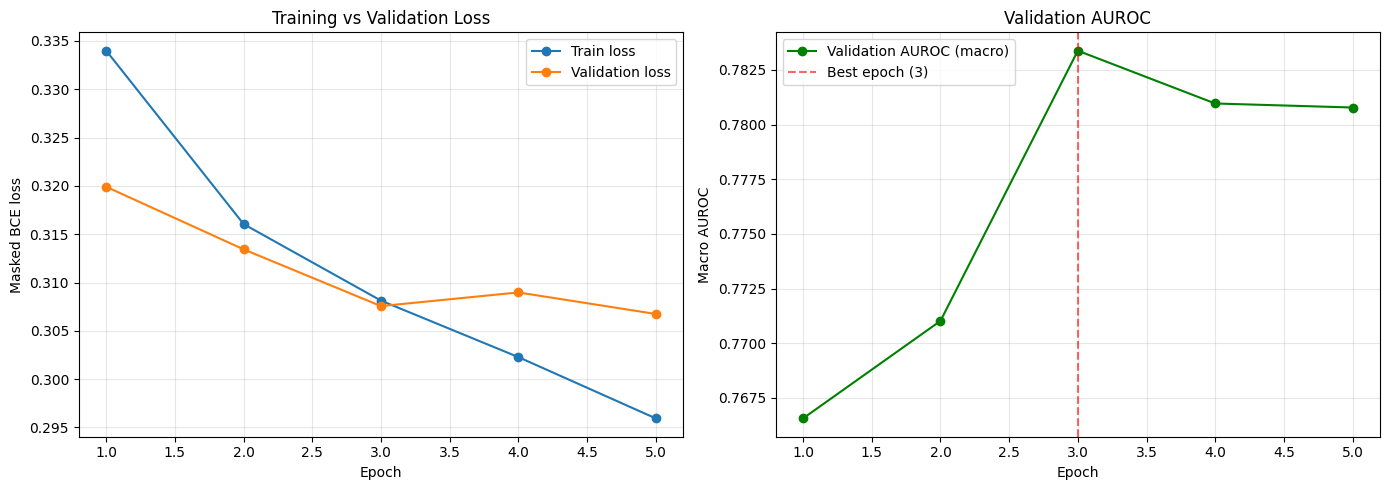

Saved training curves to /content/drive/MyDrive/CheXpert/model_artifacts/plots/training_curves.png


In [ ]:
history_df = pd.read_csv(history_csv_path)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history_df["epoch"], history_df["train_loss"], marker="o", label="Train loss")
axes[0].plot(history_df["epoch"], history_df["val_loss"], marker="o", label="Validation loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Masked BCE loss")
axes[0].set_title("Training vs Validation Loss")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(history_df["epoch"], history_df["val_auroc"], marker="o", color="green",
             label="Validation AUROC (macro)")
axes[1].axvline(best_epoch, color="red", linestyle="--", alpha=0.6,
                 label=f"Best epoch ({best_epoch})")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Macro AUROC")
axes[1].set_title("Validation AUROC")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
curves_path = OUTPUT_DIR / "plots" / "training_curves.png"
plt.savefig(curves_path, dpi=150)
plt.show()
print(f"Saved training curves to {curves_path}")


## 11. Summary

In [ ]:
print("=" * 70)
print("TRAINING COMPLETE — SUMMARY")
print("=" * 70)
print(f"Best epoch              : {best_epoch}")
print(f"Best validation AUROC   : {best_val_auroc:.4f}")
print(f"Best checkpoint path    : {best_ckpt_path}")
print(f"Latest checkpoint path  : {latest_ckpt_path}")
print(f"Training history (CSV)  : {history_csv_path}")
print(f"Configuration (JSON)    : {final_config_path}")
print(f"Uncertainty strategy    : {CONFIG['UNCERTAINTY_STRATEGY']}")
print("=" * 70)


TRAINING COMPLETE — SUMMARY
Best epoch              : 3
Best validation AUROC   : 0.7834
Best checkpoint path    : /content/drive/MyDrive/CheXpert/model_artifacts/checkpoints/best_model.pt
Latest checkpoint path  : /content/drive/MyDrive/CheXpert/model_artifacts/checkpoints/latest_model.pt
Training history (CSV)  : /content/drive/MyDrive/CheXpert/model_artifacts/logs/training_history.csv
Configuration (JSON)    : /content/drive/MyDrive/CheXpert/model_artifacts/config/config.json
Uncertainty strategy    : ones_zeros_per_pathology


## 12. Load the Best Checkpoint

Everything evaluation needs — `CONFIG`, `PATHOLOGIES`, the transforms, `df_valid_official`,
and the `test_dataset`/`val_dataset`/`test_loader`/`val_loader` built in Section 6 — is already
in memory, so there's no need to reload it from disk.

The one thing we *do* need to reload: the in-memory `model` currently holds whichever epoch
training stopped on, not necessarily the best one. We reload the weights from `best_model.pt`
so evaluation always uses the checkpoint with the highest validation AUROC.

In [26]:
checkpoint = torch.load(best_ckpt_path, map_location=device, weights_only=False)
model.load_state_dict(checkpoint["model_state_dict"])
model.eval()

print(f"Loaded best checkpoint from {best_ckpt_path}")
print(f"  epoch     : {checkpoint['epoch']}")
print(f"  val_auroc : {checkpoint['val_auroc']:.4f}")


Loaded best checkpoint from /content/drive/MyDrive/CheXpert/model_artifacts/checkpoints/best_model.pt
  epoch     : 3
  val_auroc : 0.7834


## 13. Generate & Save Predictions

We run the best model on three sets:
* **local val** (`val_loader`) — used only for threshold selection (Section 14)
* **local test** (`test_loader`) — our primary held-out evaluation set
* **official CheXpert valid** (`df_valid_official`) — an independent, radiologist-labeled sanity check

Each split's probabilities, true labels, and loss masks are saved to a single CSV.

In [27]:
def generate_predictions(model, loader, device, desc="Generating predictions"):
    model.eval()
    all_probs = []
    all_targets = []
    all_masks = []
    all_image_paths = []
    all_patient_ids = []

    with torch.no_grad():
        for images, targets, mask, image_paths in tqdm(loader, desc=desc):
            images = images.to(device, non_blocking=True)
            logits = model(images)
            probs = torch.sigmoid(logits).cpu().numpy()

            all_probs.append(probs)
            all_targets.append(targets.cpu().numpy())
            all_masks.append(mask.cpu().numpy())
            all_image_paths.extend(image_paths)
            all_patient_ids.extend(Path(p).parent.parent.name for p in image_paths)

    return (
        np.concatenate(all_probs),
        np.concatenate(all_targets),
        np.concatenate(all_masks),
        all_image_paths,
        all_patient_ids,
    )


def save_predictions_to_csv(probs, targets, masks, image_paths, patient_ids, split_name):
    """Save one combined CSV per split: image_path, patient_id, and <pathology>_prob/_true/_mask."""
    df = pd.DataFrame({"image_path": image_paths, "patient_id": patient_ids})
    for i, path in enumerate(PATHOLOGIES):
        df[f"{path}_prob"] = probs[:, i]
        df[f"{path}_true"] = targets[:, i]
        df[f"{path}_mask"] = masks[:, i]

    out_path = OUTPUT_DIR / "predictions" / f"{split_name}_predictions.csv"
    df.to_csv(out_path, index=False)
    print(f"Saved {split_name} predictions to {out_path}")


# Official CheXpert valid.csv needs its own dataset/loader (it was only ever loaded, not split).
official_valid_dataset = CheXpertDataset(
    df_valid_official, PATHOLOGIES, eval_transform, CONFIG["UNCERTAINTY_STRATEGY"]
)
official_valid_loader = DataLoader(official_valid_dataset, shuffle=False, drop_last=False, **loader_kwargs)

print("Generating predictions for the local validation set...")
val_probs, val_targets, val_masks, val_image_paths, val_patient_ids = generate_predictions(
    model, val_loader, device, desc="Local Val Predictions"
)

print("Generating predictions for the local test set...")
test_probs, test_targets, test_masks, test_image_paths, test_patient_ids = generate_predictions(
    model, test_loader, device, desc="Local Test Predictions"
)

print("Generating predictions for the official CheXpert valid set...")
official_valid_probs, official_valid_targets, official_valid_masks, \
    official_valid_image_paths, official_valid_patient_ids = generate_predictions(
        model, official_valid_loader, device, desc="Official Valid Predictions"
    )

save_predictions_to_csv(val_probs, val_targets, val_masks, val_image_paths, val_patient_ids, "local_val")
save_predictions_to_csv(test_probs, test_targets, test_masks, test_image_paths, test_patient_ids, "local_test")
save_predictions_to_csv(
    official_valid_probs, official_valid_targets, official_valid_masks,
    official_valid_image_paths, official_valid_patient_ids, "official_valid",
)
print("\nPrediction generation complete.")


Generating predictions for the local validation set...


Local Val Predictions:   0%|          | 0/349 [00:00<?, ?it/s]

Generating predictions for the local test set...


Local Test Predictions:   0%|          | 0/349 [00:00<?, ?it/s]

Generating predictions for the official CheXpert valid set...


Official Valid Predictions:   0%|          | 0/4 [00:00<?, ?it/s]

Saved local_val predictions to /content/drive/MyDrive/CheXpert/model_artifacts/predictions/local_val_predictions.csv
Saved local_test predictions to /content/drive/MyDrive/CheXpert/model_artifacts/predictions/local_test_predictions.csv
Saved official_valid predictions to /content/drive/MyDrive/CheXpert/model_artifacts/predictions/official_valid_predictions.csv

Prediction generation complete.


## 14. Evaluation Metrics

For each of the 14 CheXpert observations we compute: AUROC, PR-AUC, Brier score (all
threshold-free), plus F1, Recall, Precision, and Specificity (threshold-dependent).

In [28]:
def calculate_metrics(y_true, y_prob, y_pred):
    """Calculate all metrics for one pathology.

    y_true : binary ground-truth labels
    y_prob : predicted probabilities
    y_pred : binary predictions after thresholding
    """
    metrics = {}

    # AUROC / PR-AUC require both positive and negative examples.
    unique_classes = np.unique(y_true)
    if len(unique_classes) >= 2:
        metrics["AUROC"] = roc_auc_score(y_true, y_prob)
        metrics["PR-AUC"] = average_precision_score(y_true, y_prob)
    else:
        metrics["AUROC"] = np.nan
        metrics["PR-AUC"] = np.nan

    # Brier score is still meaningful even if only one class exists.
    metrics["Brier Score"] = brier_score_loss(y_true, y_prob)

    # Threshold-dependent metrics.
    metrics["F1"] = f1_score(y_true, y_pred, zero_division=0)
    metrics["Recall"] = recall_score(y_true, y_pred, zero_division=0)
    metrics["Precision"] = precision_score(y_true, y_pred, zero_division=0)

    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    metrics["Specificity"] = tn / (tn + fp) if (tn + fp) > 0 else np.nan

    metrics["N"] = len(y_true)
    metrics["Positive"] = int(np.sum(y_true == 1))
    metrics["Negative"] = int(np.sum(y_true == 0))

    return metrics


### Threshold Selection (Validation Set)

We select one probability threshold per pathology by maximizing F1 on the **local validation
set**, then freeze those thresholds for every dataset we evaluate below. This keeps the local
test set and the official CheXpert valid set free of any threshold leakage.

In [29]:
def find_optimal_threshold(y_true, y_prob):
    """Find the probability threshold that maximizes F1 on the validation set."""
    if len(np.unique(y_true)) < 2:
        return 0.5, np.nan

    thresholds = np.linspace(0.01, 0.99, 199)
    best_threshold, best_f1 = 0.5, -1.0

    for threshold in thresholds:
        y_pred = (y_prob >= threshold).astype(np.int8)
        current_f1 = f1_score(y_true, y_pred, zero_division=0)
        if current_f1 > best_f1:
            best_f1 = current_f1
            best_threshold = threshold

    return best_threshold, best_f1


optimal_thresholds = {}
threshold_rows = []

print("Selecting optimal thresholds from the local validation set...\n")
for i, pathology in enumerate(PATHOLOGIES):
    valid = val_masks[:, i] == 1
    y_true = val_targets[valid, i].astype(int)
    y_prob = val_probs[valid, i]

    threshold, best_f1 = find_optimal_threshold(y_true, y_prob)
    optimal_thresholds[pathology] = threshold

    threshold_rows.append({
        "Pathology": pathology,
        "Threshold": threshold,
        "Validation F1": best_f1,
        "N": len(y_true),
        "Positive": int(np.sum(y_true == 1)),
        "Negative": int(np.sum(y_true == 0)),
    })
    print(f"{pathology:30s} threshold={threshold:.3f} val_F1={best_f1:.4f}")

thresholds_df = pd.DataFrame(threshold_rows)
thresholds_path = OUTPUT_DIR / "metrics" / "thresholds.csv"
thresholds_df.to_csv(thresholds_path, index=False)
print(f"\nThresholds saved to: {thresholds_path}")


Selecting optimal thresholds from the local validation set...

No Finding                     threshold=0.500 val_F1=nan
Enlarged Cardiomediastinum     threshold=0.545 val_F1=0.5198
Cardiomegaly                   threshold=0.322 val_F1=0.8204
Lung Lesion                    threshold=0.154 val_F1=0.8705
Lung Opacity                   threshold=0.074 val_F1=0.9464
Edema                          threshold=0.238 val_F1=0.9076
Consolidation                  threshold=0.564 val_F1=0.5301
Pneumonia                      threshold=0.213 val_F1=0.8251
Atelectasis                    threshold=0.079 val_F1=0.9916
Pneumothorax                   threshold=0.614 val_F1=0.6293
Pleural Effusion               threshold=0.277 val_F1=0.9297
Pleural Other                  threshold=0.342 val_F1=0.6751
Fracture                       threshold=0.302 val_F1=0.8579
Support Devices                threshold=0.045 val_F1=0.9699

Thresholds saved to: /content/drive/MyDrive/CheXpert/model_artifacts/metrics/threshol

### Evaluate a Dataset

One function evaluates any dataset (probabilities/targets/masks) against the frozen
validation-set thresholds, prints a metrics table, and saves it to CSV. We use it for both
the local test set and the official CheXpert valid set below, so the two are always scored
identically.

In [30]:
def evaluate_dataset(probs, targets, masks, dataset_name, thresholds):
    """Evaluate one dataset using pre-selected per-pathology thresholds."""
    metrics_rows = []

    print("\n" + "=" * 80)
    print(f"EVALUATING: {dataset_name}")
    print("=" * 80)

    for i, pathology in enumerate(PATHOLOGIES):
        valid = masks[:, i] == 1
        y_true = targets[valid, i].astype(int)
        y_prob = probs[valid, i]

        threshold = thresholds[pathology]
        y_pred = (y_prob >= threshold).astype(np.int8)

        metrics = calculate_metrics(y_true=y_true, y_prob=y_prob, y_pred=y_pred)
        metrics_rows.append({
            "Pathology": pathology,
            "AUROC": metrics["AUROC"],
            "PR-AUC": metrics["PR-AUC"],
            "Brier Score": metrics["Brier Score"],
            "Threshold": threshold,
            "F1": metrics["F1"],
            "Recall": metrics["Recall"],
            "Precision": metrics["Precision"],
            "Specificity": metrics["Specificity"],
            "N": metrics["N"],
            "Positive": metrics["Positive"],
            "Negative": metrics["Negative"],
        })

    metrics_df = pd.DataFrame(metrics_rows)

    macro_metrics = {
        "Pathology": "Macro Avg",
        "AUROC": metrics_df["AUROC"].mean(skipna=True),
        "PR-AUC": metrics_df["PR-AUC"].mean(skipna=True),
        "Brier Score": metrics_df["Brier Score"].mean(skipna=True),
        "Threshold": np.nan,
        "F1": metrics_df["F1"].mean(skipna=True),
        "Recall": metrics_df["Recall"].mean(skipna=True),
        "Precision": metrics_df["Precision"].mean(skipna=True),
        "Specificity": metrics_df["Specificity"].mean(skipna=True),
        "N": metrics_df["N"].sum(),
        "Positive": metrics_df["Positive"].sum(),
        "Negative": metrics_df["Negative"].sum(),
    }
    metrics_df = pd.concat([metrics_df, pd.DataFrame([macro_metrics])], ignore_index=True)

    print(metrics_df.round(4).to_markdown(index=False))

    safe_name = dataset_name.lower().replace(" ", "_").replace("-", "_")
    output_path = OUTPUT_DIR / "metrics" / f"{safe_name}_metrics.csv"
    metrics_df.to_csv(output_path, index=False)
    print(f"\nMetrics saved to: {output_path}")

    return metrics_df


In [31]:
test_metrics_df = evaluate_dataset(
    probs=test_probs, targets=test_targets, masks=test_masks,
    dataset_name="Local Test", thresholds=optimal_thresholds,
)



EVALUATING: Local Test
| Pathology                  |    AUROC |   PR-AUC |   Brier Score |   Threshold |     F1 |   Recall |   Precision |   Specificity |     N |   Positive |   Negative |
|:---------------------------|---------:|---------:|--------------:|------------:|-------:|---------:|------------:|--------------:|------:|-----------:|-----------:|
| No Finding                 | nan      | nan      |        0.3363 |      0.5    | 0.1839 |   0.1012 |      1      |      nan      |  2252 |       2252 |          0 |
| Enlarged Cardiomediastinum |   0.7601 |   0.5073 |        0.2179 |      0.5445 | 0.509  |   0.7021 |      0.3992 |        0.6837 |  4445 |       1024 |       3421 |
| Cardiomegaly               |   0.8366 |   0.8656 |        0.1636 |      0.3218 | 0.8107 |   0.9049 |      0.7343 |        0.5549 |  4638 |       2672 |       1966 |
| Lung Lesion                |   0.6382 |   0.8408 |        0.268  |      0.1535 | 0.8672 |   0.9934 |      0.7694 |        0.0074 |  1179 | 

In [32]:
official_valid_metrics_df = evaluate_dataset(
    probs=official_valid_probs, targets=official_valid_targets, masks=official_valid_masks,
    dataset_name="Official CheXpert Valid", thresholds=optimal_thresholds,
)



EVALUATING: Official CheXpert Valid
| Pathology                  |    AUROC |   PR-AUC |   Brier Score |   Threshold |     F1 |   Recall |   Precision |   Specificity |    N |   Positive |   Negative |
|:---------------------------|---------:|---------:|--------------:|------------:|-------:|---------:|------------:|--------------:|-----:|-----------:|-----------:|
| No Finding                 |   0.3769 |   0.1248 |        0.2209 |      0.5    | 0      |   0      |      0      |        0.8367 |  234 |         38 |        196 |
| Enlarged Cardiomediastinum |   0.8961 |   0.8751 |        0.1482 |      0.5445 | 0.8036 |   0.8257 |      0.7826 |        0.8    |  234 |        109 |        125 |
| Cardiomegaly               |   0.8708 |   0.7452 |        0.1324 |      0.3218 | 0.6441 |   0.8382 |      0.5229 |        0.6867 |  234 |         68 |        166 |
| Lung Lesion                |   0.8112 |   0.0222 |        0.2159 |      0.1535 | 0.0085 |   1      |      0.0043 |        0.0043 | 

### Local Test vs Official CheXpert Valid

A quick side-by-side of the macro-averaged metrics on both held-out sets.

In [33]:
test_macro = test_metrics_df[test_metrics_df["Pathology"] == "Macro Avg"].iloc[0]
official_macro = official_valid_metrics_df[official_valid_metrics_df["Pathology"] == "Macro Avg"].iloc[0]

comparison_df = pd.DataFrame({
    "Metric": ["AUROC", "PR-AUC", "Brier Score", "F1", "Recall", "Precision", "Specificity"],
    "Local Test": [
        test_macro["AUROC"], test_macro["PR-AUC"], test_macro["Brier Score"],
        test_macro["F1"], test_macro["Recall"], test_macro["Precision"], test_macro["Specificity"],
    ],
    "Official CheXpert Valid": [
        official_macro["AUROC"], official_macro["PR-AUC"], official_macro["Brier Score"],
        official_macro["F1"], official_macro["Recall"], official_macro["Precision"], official_macro["Specificity"],
    ],
})

print("\n" + "=" * 80)
print("FINAL DATASET COMPARISON")
print("=" * 80)
print(comparison_df.round(4).to_markdown(index=False))

comparison_path = OUTPUT_DIR / "metrics" / "local_test_vs_official_valid_comparison.csv"
comparison_df.to_csv(comparison_path, index=False)
print(f"\nComparison saved to: {comparison_path}")



FINAL DATASET COMPARISON
| Metric      |   Local Test |   Official CheXpert Valid |
|:------------|-------------:|--------------------------:|
| AUROC       |       0.7843 |                    0.8271 |
| PR-AUC      |       0.8222 |                    0.5252 |
| Brier Score |       0.193  |                    0.2089 |
| F1          |       0.7624 |                    0.3705 |
| Recall      |       0.845  |                    0.7729 |
| Precision   |       0.7573 |                    0.2853 |
| Specificity |       0.3707 |                    0.3874 |

Comparison saved to: /content/drive/MyDrive/CheXpert/model_artifacts/metrics/local_test_vs_official_valid_comparison.csv


## 16. ROC Curves

Receiver Operating Characteristic curves for all 14 pathologies on the local test set: False
Positive Rate vs. True Positive Rate, with AUROC in the legend, alongside a random baseline.

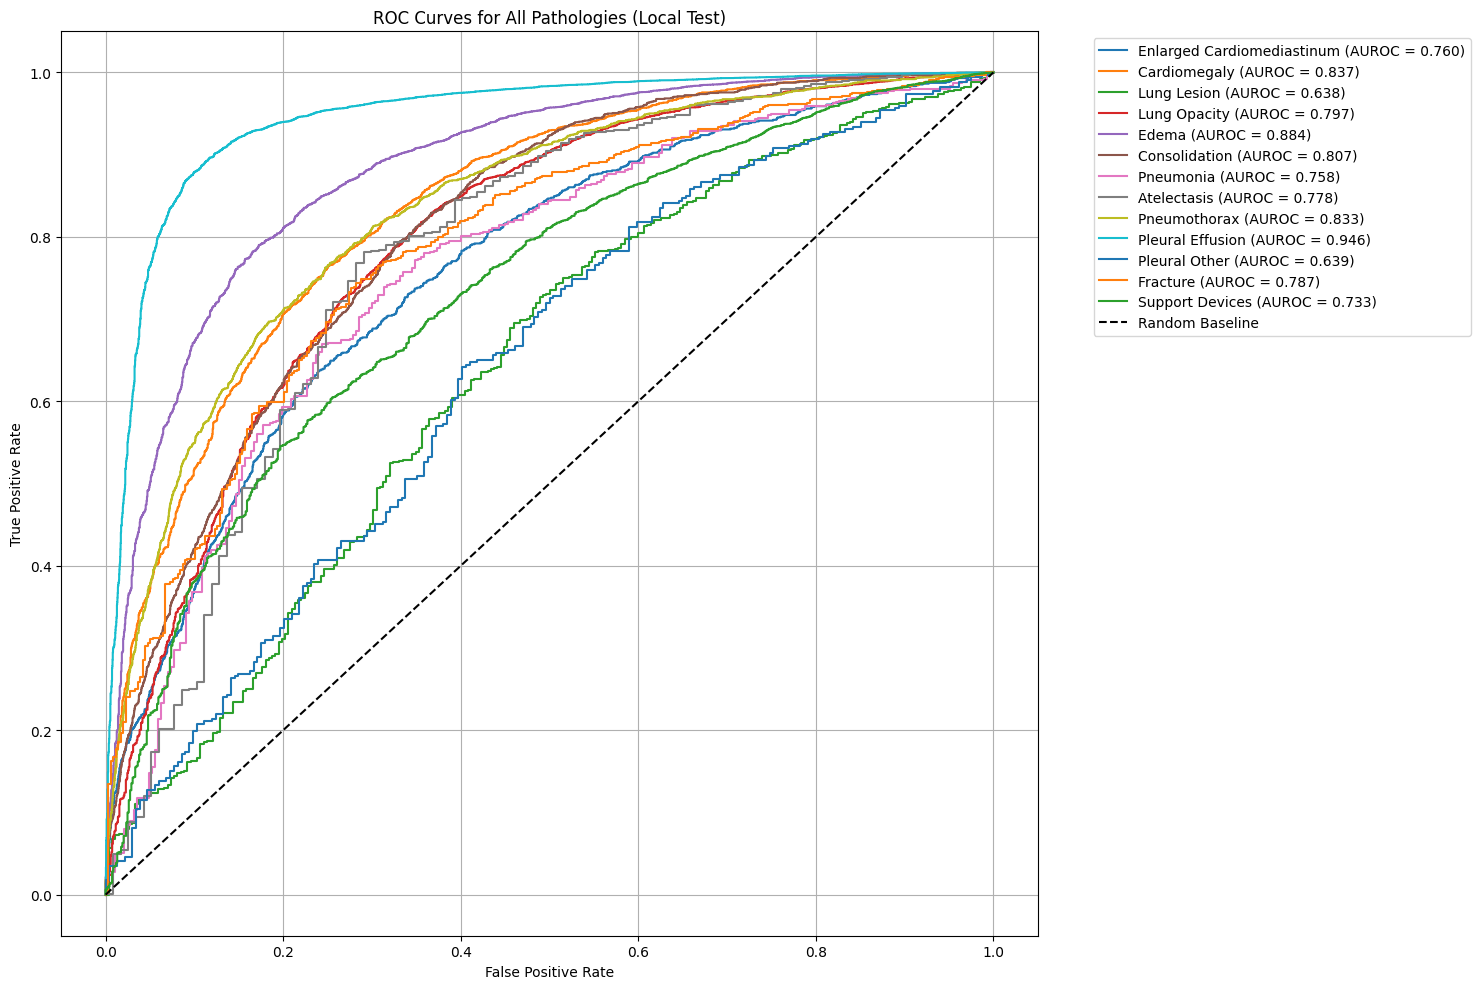

ROC curves saved to /content/drive/MyDrive/CheXpert/model_artifacts/plots/roc_curves.png


In [34]:
plt.figure(figsize=(15, 10))

for i, pathology in enumerate(PATHOLOGIES):
    valid = test_masks[:, i] == 1
    y_true = test_targets[valid, i]
    y_prob = test_probs[valid, i]

    if len(np.unique(y_true)) < 2:
        print(f"Warning: Not enough unique classes for {pathology} to plot ROC curve. Skipping.")
        continue

    fpr, tpr, _ = roc_curve(y_true, y_prob)
    auroc = roc_auc_score(y_true, y_prob)
    plt.plot(fpr, tpr, label=f"{pathology} (AUROC = {auroc:.3f})")

plt.plot([0, 1], [0, 1], "k--", label="Random Baseline")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves for All Pathologies (Local Test)")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.grid(True)
plt.tight_layout()

roc_curves_path = OUTPUT_DIR / "plots" / "roc_curves.png"
plt.savefig(roc_curves_path, dpi=300)
plt.show()
print(f"ROC curves saved to {roc_curves_path}")


## 17. Precision-Recall Curves

PR curves are more informative than ROC curves on imbalanced classes. We plot Precision vs.
Recall for all 14 pathologies, with PR-AUC in the legend.

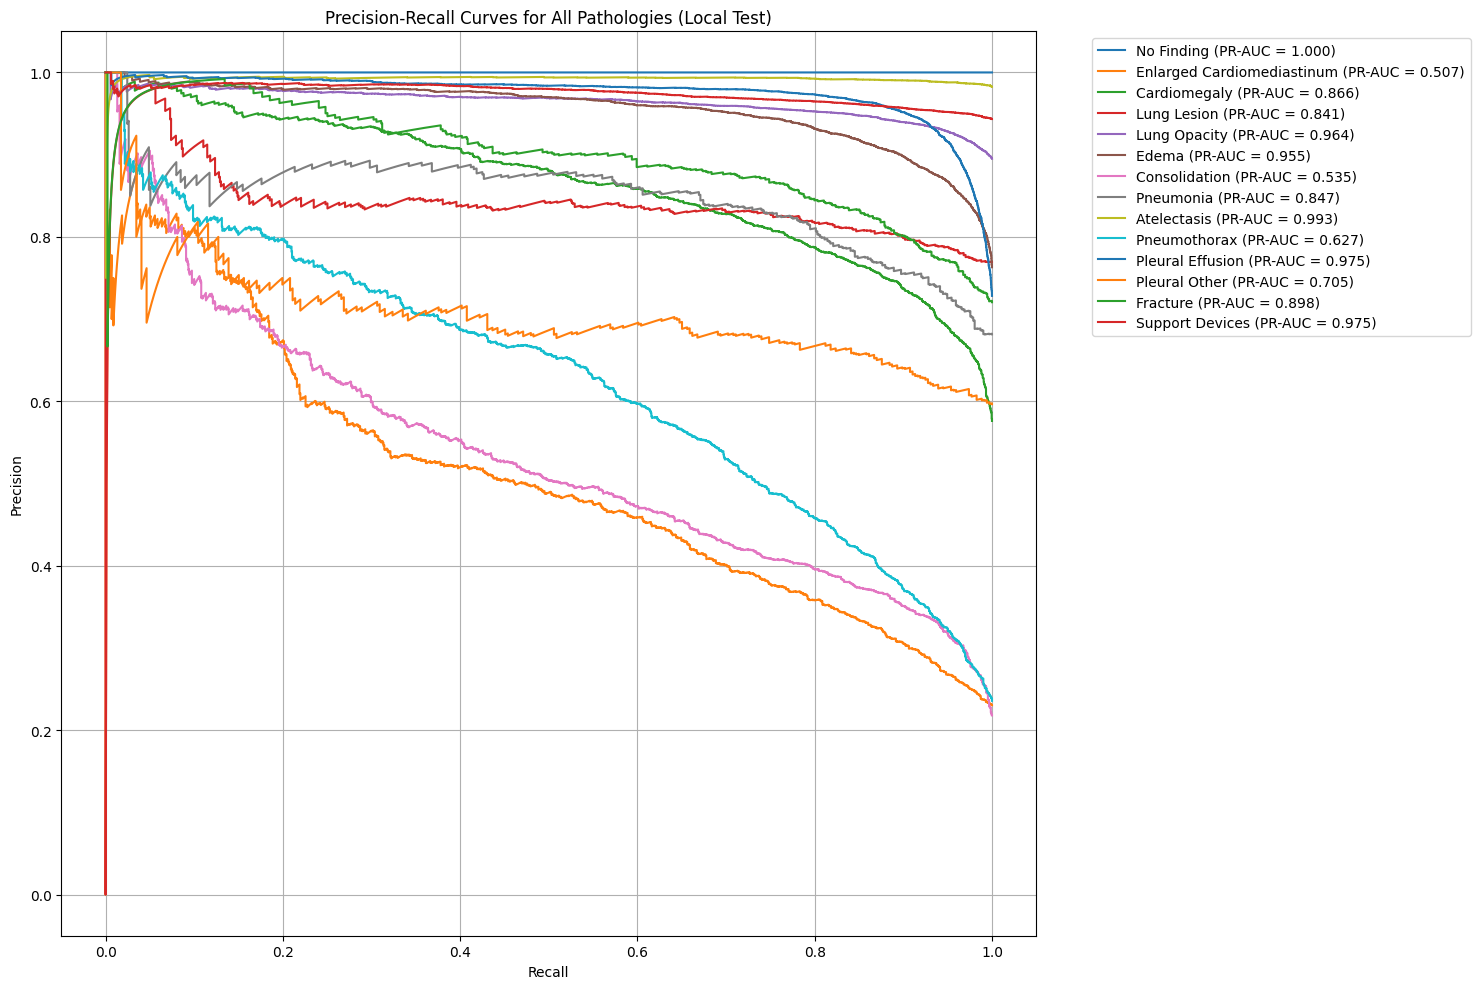

Precision-Recall curves saved to /content/drive/MyDrive/CheXpert/model_artifacts/plots/pr_curves.png


In [35]:
plt.figure(figsize=(15, 10))

for i, pathology in enumerate(PATHOLOGIES):
    valid = test_masks[:, i] == 1
    y_true = test_targets[valid, i]
    y_prob = test_probs[valid, i]

    if np.sum(y_true) == 0:
        print(f"Warning: No positive samples for {pathology} to plot PR curve. Skipping.")
        continue

    precision, recall, _ = precision_recall_curve(y_true, y_prob)
    pr_auc = average_precision_score(y_true, y_prob)
    plt.plot(recall, precision, label=f"{pathology} (PR-AUC = {pr_auc:.3f})")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curves for All Pathologies (Local Test)")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.grid(True)
plt.tight_layout()

pr_curves_path = OUTPUT_DIR / "plots" / "pr_curves.png"
plt.savefig(pr_curves_path, dpi=300)
plt.show()
print(f"Precision-Recall curves saved to {pr_curves_path}")


### AUROC and PR-AUC Comparison Bar Charts

A quick per-pathology overview, excluding the Macro Avg row.

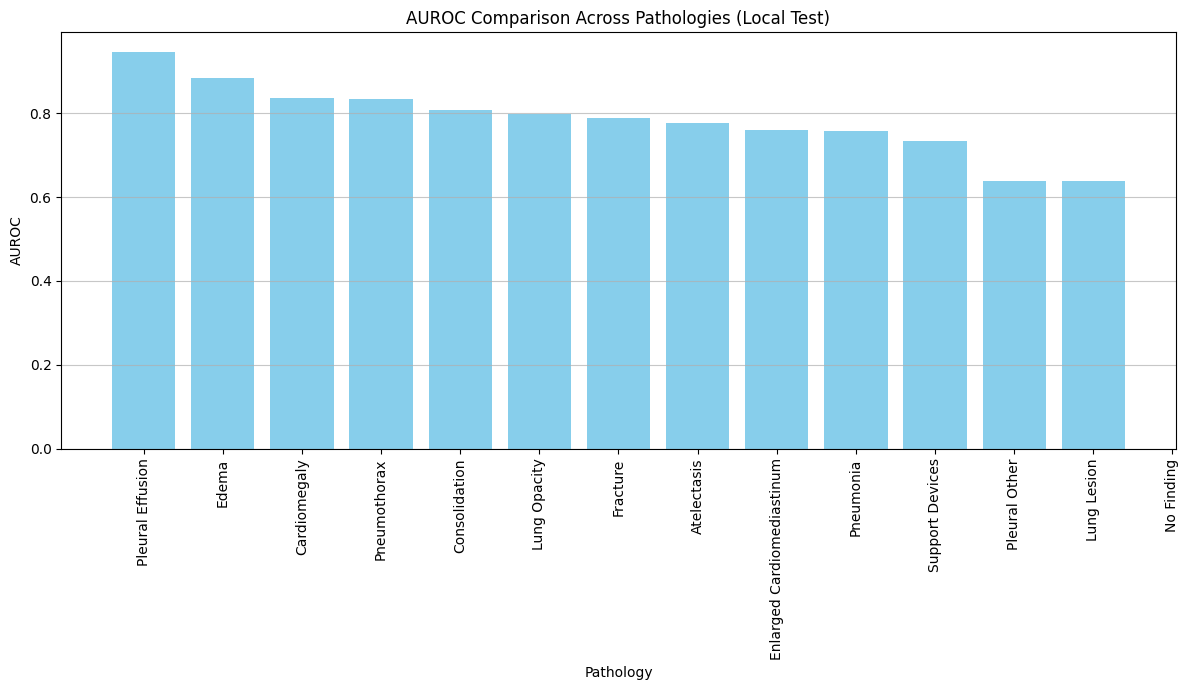

AUROC comparison bar chart saved to /content/drive/MyDrive/CheXpert/model_artifacts/plots/auroc_comparison.png


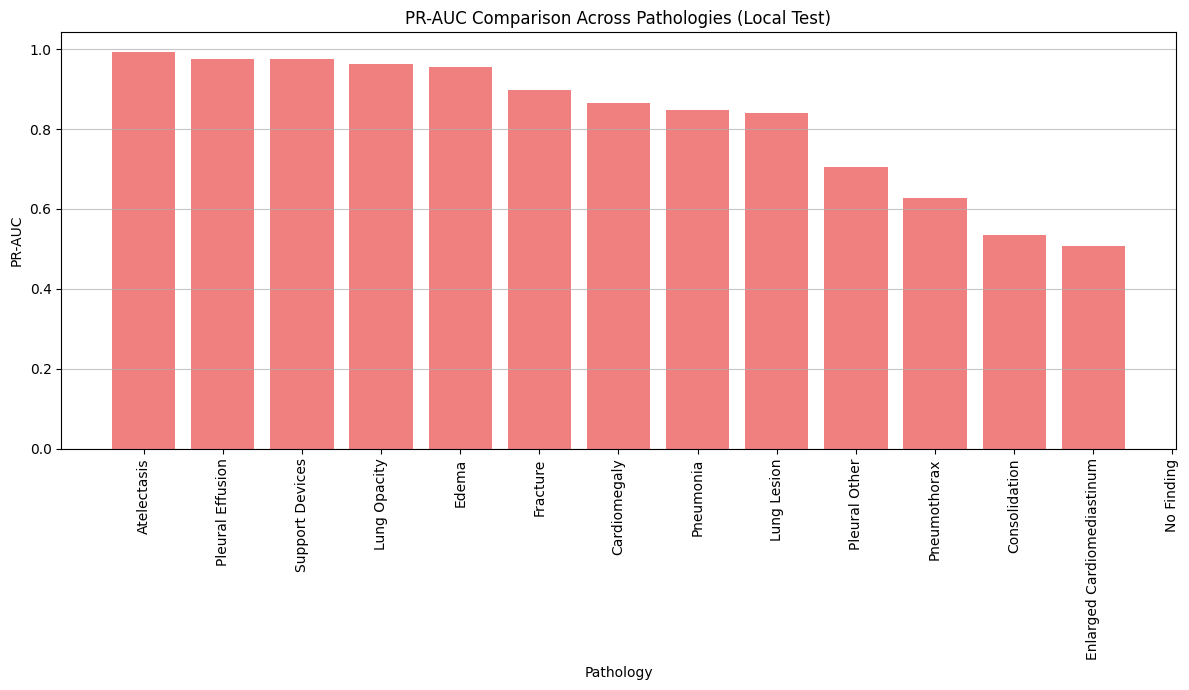

PR-AUC comparison bar chart saved to /content/drive/MyDrive/CheXpert/model_artifacts/plots/prauc_comparison.png


In [36]:
metrics_for_plot_df = test_metrics_df[test_metrics_df["Pathology"] != "Macro Avg"]

# Bar chart for AUROC
plot_df = metrics_for_plot_df.sort_values(by="AUROC", ascending=False)
plt.figure(figsize=(12, 7))
plt.bar(plot_df["Pathology"], plot_df["AUROC"], color="skyblue")
plt.xlabel("Pathology")
plt.ylabel("AUROC")
plt.title("AUROC Comparison Across Pathologies (Local Test)")
plt.xticks(rotation=90)
plt.grid(axis="y", alpha=0.7)
plt.tight_layout()
auroc_comparison_path = OUTPUT_DIR / "plots" / "auroc_comparison.png"
plt.savefig(auroc_comparison_path, dpi=300)
plt.show()
print(f"AUROC comparison bar chart saved to {auroc_comparison_path}")

# Bar chart for PR-AUC
plot_df = metrics_for_plot_df.sort_values(by="PR-AUC", ascending=False)
plt.figure(figsize=(12, 7))
plt.bar(plot_df["Pathology"], plot_df["PR-AUC"], color="lightcoral")
plt.xlabel("Pathology")
plt.ylabel("PR-AUC")
plt.title("PR-AUC Comparison Across Pathologies (Local Test)")
plt.xticks(rotation=90)
plt.grid(axis="y", alpha=0.7)
plt.tight_layout()
prauc_comparison_path = OUTPUT_DIR / "plots" / "prauc_comparison.png"
plt.savefig(prauc_comparison_path, dpi=300)
plt.show()
print(f"PR-AUC comparison bar chart saved to {prauc_comparison_path}")


## 18. Confusion Matrices

One binary confusion matrix per pathology on the local test set, using the thresholds
selected from the validation set.

In [37]:
confusion_matrices_dir = OUTPUT_DIR / "plots" / "confusion_matrices"
confusion_matrices_dir.mkdir(parents=True, exist_ok=True)

print("Generating confusion matrices...")
for i, pathology in enumerate(PATHOLOGIES):
    valid = test_masks[:, i] == 1
    y_true = test_targets[valid, i]
    y_prob = test_probs[valid, i]

    if len(y_true) == 0:
        print(f"Warning: No valid test samples for pathology '{pathology}'. Skipping confusion matrix.")
        continue

    threshold = optimal_thresholds[pathology]
    y_pred = (y_prob >= threshold).astype(int)

    cm = confusion_matrix(y_true, y_pred)
    # Handle the case where only one class is present after filtering.
    if cm.shape == (1, 1):
        if y_true[0] == 0:
            tn, fp, fn, tp = cm[0, 0], 0, 0, 0
        else:
            tn, fp, fn, tp = 0, 0, 0, cm[0, 0]
        cm = np.array([[tn, fp], [fn, tp]])

    plt.figure(figsize=(4, 3))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
                xticklabels=["Predicted 0", "Predicted 1"],
                yticklabels=["Actual 0", "Actual 1"])
    plt.title(f"Confusion Matrix: {pathology} (Threshold: {threshold:.2f})")
    plt.ylabel("Actual Label")
    plt.xlabel("Predicted Label")
    plt.tight_layout()
    cm_path = confusion_matrices_dir / f'confusion_matrix_{pathology.replace(" ", "_")}.png'
    plt.savefig(cm_path, dpi=200)
    plt.close()

print(f"Confusion matrices saved to {confusion_matrices_dir}")


Generating confusion matrices...
Confusion matrices saved to /content/drive/MyDrive/CheXpert/model_artifacts/plots/confusion_matrices


## 19. Calibration

Calibration (reliability) plots show how well predicted probabilities align with observed
frequencies. We show these for a few representative pathologies spanning different AUROC
levels.

In [38]:
calibration_plots_dir = OUTPUT_DIR / "plots" / "calibration"
calibration_plots_dir.mkdir(parents=True, exist_ok=True)

representative_pathologies = [
    "Edema",         # High AUROC
    "Pneumonia",     # Lower AUROC
    "Cardiomegaly",  # Medium AUROC
    "Atelectasis",   # Can have unique calibration behavior due to uncertainty handling
]

print("Generating calibration plots...")
for pathology in representative_pathologies:
    i = PATHOLOGIES.index(pathology)
    valid = test_masks[:, i] == 1
    y_true = test_targets[valid, i]
    y_prob = test_probs[valid, i]

    if len(y_true) == 0 or len(np.unique(y_true)) < 2:
        print(f"Warning: Not enough valid or diverse samples for {pathology} to plot calibration curve. Skipping.")
        continue

    fraction_of_positives, mean_predicted_value = calibration_curve(y_true, y_prob, n_bins=10)

    plt.figure(figsize=(6, 6))
    plt.plot([0, 1], [0, 1], "k:", label="Perfectly calibrated")
    plt.plot(mean_predicted_value, fraction_of_positives, "s-", label=pathology)
    plt.xlabel("Mean predicted probability")
    plt.ylabel("Fraction of positives (observed frequency)")
    plt.title(f"Calibration Plot: {pathology}")
    plt.legend(loc="lower right")
    plt.grid(True)
    plt.tight_layout()
    calibration_path = calibration_plots_dir / f"calibration_plot_{pathology.replace(' ', '_')}.png"
    plt.savefig(calibration_path, dpi=200)
    plt.close()

print(f"Calibration plots saved to {calibration_plots_dir}")


Generating calibration plots...
Calibration plots saved to /content/drive/MyDrive/CheXpert/model_artifacts/plots/calibration


## 20. Grad-CAM

Grad-CAM (Gradient-weighted Class Activation Mapping) visualizes which regions of an input
image most influenced the model's prediction for a given class.

**Important:** Grad-CAM shows image regions that *influenced the model's prediction*. It does
NOT prove that the model is medically reasoning correctly or that the highlighted region
represents the pathology. It's a tool for interpretability, not medical diagnosis.

In [39]:
def get_representative_images(dataset, num_samples_per_pathology=1, seed=RANDOM_SEED):
    """Selects a few images where a given pathology is positive."""
    selected_samples = []
    rng = np.random.RandomState(seed)

    for i, pathology in enumerate(PATHOLOGIES):
        positive_and_valid_indices = [
            idx for idx in range(len(dataset))
            if dataset.targets[idx, i] == 1 and dataset.masks[idx, i] == 1
        ]
        if len(positive_and_valid_indices) > 0:
            chosen_indices = rng.choice(
                positive_and_valid_indices,
                size=min(num_samples_per_pathology, len(positive_and_valid_indices)),
                replace=False,
            )
            for idx in chosen_indices:
                image, target, mask, path = dataset[idx]
                selected_samples.append({
                    "pathology_idx": i,
                    "pathology_name": pathology,
                    "image_tensor": image,
                    "true_target": target,
                    "mask": mask,
                    "image_path": path,
                    "dataset_idx": idx,
                })
    return selected_samples


num_gradcam_examples = 2  # examples per pathology
representative_images = get_representative_images(test_dataset, num_gradcam_examples)
print(f"Selected {len(representative_images)} images for Grad-CAM visualization.")


Selected 28 images for Grad-CAM visualization.


In [40]:
# For DenseNet-121, the last convolutional block's final BN layer works well as the target layer.
target_layers = [model.features.norm5]
cam = GradCAM(model=model, target_layers=target_layers)

gradcam_output_dir = OUTPUT_DIR / "gradcam"
gradcam_output_dir.mkdir(parents=True, exist_ok=True)

print("Generating Grad-CAM visualizations...")
for i, sample in enumerate(representative_images):
    pathology_idx = sample["pathology_idx"]
    pathology_name = sample["pathology_name"]
    image_tensor = sample["image_tensor"].unsqueeze(0).to(device)

    model.eval()
    with torch.no_grad():
        logits = model(image_tensor)
        probs = torch.sigmoid(logits).cpu().numpy().flatten()
    predicted_prob = probs[pathology_idx]

    targets = [ClassifierOutputTarget(pathology_idx)]
    grayscale_cam = cam(input_tensor=image_tensor, targets=targets, aug_smooth=True, eigen_smooth=True)
    grayscale_cam = grayscale_cam[0, :]

    original_image_np = denormalize(sample["image_tensor"]).permute(1, 2, 0).numpy()
    cam_image = show_cam_on_image(original_image_np, grayscale_cam, use_rgb=True)

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    axes[0].imshow(original_image_np)
    axes[0].set_title("Original Image")
    axes[0].axis("off")

    axes[1].imshow(grayscale_cam, cmap="jet", alpha=0.8)
    axes[1].set_title("Grad-CAM Heatmap")
    axes[1].axis("off")

    axes[2].imshow(cam_image)
    axes[2].set_title("Overlayed Grad-CAM")
    axes[2].axis("off")

    plt.suptitle(f"Pathology: {pathology_name} | Predicted Prob: {predicted_prob:.4f}", fontsize=16)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])

    gradcam_filename = f"gradcam_{pathology_name.replace(' ', '_')}_{i}.png"
    plt.savefig(gradcam_output_dir / gradcam_filename, dpi=200)
    plt.close(fig)

print(f"Grad-CAM visualizations saved to {gradcam_output_dir}")


Generating Grad-CAM visualizations...
Grad-CAM visualizations saved to /content/drive/MyDrive/CheXpert/model_artifacts/gradcam


## 21. Final Results Summary

Key macro-average metrics on the local test set, plus the best- and worst-performing
pathologies by AUROC.

In [41]:
macro_row = test_metrics_df[test_metrics_df["Pathology"] == "Macro Avg"].iloc[0]

final_summary = {
    "best_validation_auroc": best_val_auroc,
    "test_macro_auroc": macro_row["AUROC"],
    "test_macro_prauc": macro_row["PR-AUC"],
    "test_macro_f1": macro_row["F1"],
    "test_macro_recall": macro_row["Recall"],
    "test_macro_precision": macro_row["Precision"],
    "test_macro_specificity": macro_row["Specificity"],
    "test_macro_brier_score": macro_row["Brier Score"],
    "official_valid_macro_auroc": official_macro["AUROC"],
    "official_valid_macro_prauc": official_macro["PR-AUC"],
}

metrics_for_ranking = test_metrics_df[
    ~test_metrics_df["Pathology"].isin(["No Finding", "Macro Avg"])
].dropna(subset=["AUROC"])

if not metrics_for_ranking.empty:
    best_pathology_auroc = metrics_for_ranking.loc[metrics_for_ranking["AUROC"].idxmax()]
    worst_pathology_auroc = metrics_for_ranking.loc[metrics_for_ranking["AUROC"].idxmin()]
    final_summary["best_performing_pathology_auroc"] = {
        "name": best_pathology_auroc["Pathology"], "auroc": best_pathology_auroc["AUROC"]
    }
    final_summary["worst_performing_pathology_auroc"] = {
        "name": worst_pathology_auroc["Pathology"], "auroc": worst_pathology_auroc["AUROC"]
    }
else:
    print("Warning: Could not determine best/worst performing pathologies based on AUROC.")

print("=" * 40)
print("FINAL RESULTS SUMMARY")
print("=" * 40)
for key, value in final_summary.items():
    if isinstance(value, dict):
        print(f"{key.replace('_', ' ').title()}: ")
        for sub_key, sub_value in value.items():
            if isinstance(sub_value, (int, float)):
                print(f"  {sub_key.replace('_', ' ').title()}: {sub_value:.4f}")
            else:
                print(f"  {sub_key.replace('_', ' ').title()}: {sub_value}")
    elif isinstance(value, (int, float)):
        print(f"{key.replace('_', ' ').title()}: {value:.4f}")
    else:
        print(f"{key.replace('_', ' ').title()}: {value}")
print("=" * 40)

final_summary_path = OUTPUT_DIR / "metrics" / "final_summary.json"
with open(final_summary_path, "w") as f:
    json.dump(final_summary, f, indent=2)
print(f"\nFinal summary saved to {final_summary_path}")


FINAL RESULTS SUMMARY
Best Validation Auroc: -inf
Test Macro Auroc: 0.7843
Test Macro Prauc: 0.8222
Test Macro F1: 0.7624
Test Macro Recall: 0.8450
Test Macro Precision: 0.7573
Test Macro Specificity: 0.3707
Test Macro Brier Score: 0.1930
Official Valid Macro Auroc: 0.8271
Official Valid Macro Prauc: 0.5252
Best Performing Pathology Auroc: 
  Name: Pleural Effusion
  Auroc: 0.9456
Worst Performing Pathology Auroc: 
  Name: Lung Lesion
  Auroc: 0.6382

Final summary saved to /content/drive/MyDrive/CheXpert/model_artifacts/metrics/final_summary.json


## 22. Verify Output Directory Structure

In [42]:
print(f"Verifying output directory structure at {OUTPUT_DIR}/")

def check_path(path_obj, is_file=False):
    exists = path_obj.exists()
    status = "\u2705 Exists" if exists else "\u274c MISSING"
    type_str = "file" if is_file else "directory"
    print(f"- {status} {type_str}: {path_obj.relative_to(OUTPUT_DIR)}")
    return exists

print("\nTop-level directories:")
for sub in SUBDIRS:
    check_path(OUTPUT_DIR / sub)

print("\nCheckpoint files:")
check_path(OUTPUT_DIR / "checkpoints" / "best_model.pt", is_file=True)
check_path(OUTPUT_DIR / "checkpoints" / "latest_model.pt", is_file=True)

print("\nLog files:")
check_path(OUTPUT_DIR / "logs" / "training_history.csv", is_file=True)

print("\nMetrics files:")
check_path(OUTPUT_DIR / "metrics" / "local_test_metrics.csv", is_file=True)
check_path(OUTPUT_DIR / "metrics" / "official_chexpert_valid_metrics.csv", is_file=True)
check_path(OUTPUT_DIR / "metrics" / "local_test_vs_official_valid_comparison.csv", is_file=True)
check_path(OUTPUT_DIR / "metrics" / "thresholds.csv", is_file=True)
check_path(OUTPUT_DIR / "metrics" / "final_summary.json", is_file=True)
check_path(OUTPUT_DIR / "metrics" / "dataset_statistics.json", is_file=True)

print("\nPrediction files:")
check_path(OUTPUT_DIR / "predictions" / "local_val_predictions.csv", is_file=True)
check_path(OUTPUT_DIR / "predictions" / "local_test_predictions.csv", is_file=True)
check_path(OUTPUT_DIR / "predictions" / "official_valid_predictions.csv", is_file=True)

print("\nPlot files:")
check_path(OUTPUT_DIR / "plots" / "training_curves.png", is_file=True)
check_path(OUTPUT_DIR / "plots" / "roc_curves.png", is_file=True)
check_path(OUTPUT_DIR / "plots" / "pr_curves.png", is_file=True)
check_path(OUTPUT_DIR / "plots" / "auroc_comparison.png", is_file=True)
check_path(OUTPUT_DIR / "plots" / "prauc_comparison.png", is_file=True)
check_path(OUTPUT_DIR / "plots" / "label_distribution.png", is_file=True)
check_path(OUTPUT_DIR / "plots" / "dataset_sample.png", is_file=True)
check_path(OUTPUT_DIR / "plots" / "calibration")     # per-pathology plots inside
check_path(OUTPUT_DIR / "plots" / "confusion_matrices")  # per-pathology plots inside

print("\nGrad-CAM directory:")
check_path(OUTPUT_DIR / "gradcam")

print("\nConfig files:")
check_path(OUTPUT_DIR / "config" / "config.json", is_file=True)
check_path(OUTPUT_DIR / "config" / "split_train.csv", is_file=True)
check_path(OUTPUT_DIR / "config" / "split_val.csv", is_file=True)
check_path(OUTPUT_DIR / "config" / "split_test.csv", is_file=True)
check_path(OUTPUT_DIR / "config" / "random_seed.txt", is_file=True)

print("\nOutput directory verification complete.")


Verifying output directory structure at /content/drive/MyDrive/CheXpert/model_artifacts/

Top-level directories:
- ✅ Exists directory: checkpoints
- ✅ Exists directory: logs
- ✅ Exists directory: plots
- ✅ Exists directory: predictions
- ✅ Exists directory: metrics
- ✅ Exists directory: gradcam
- ✅ Exists directory: config

Checkpoint files:
- ✅ Exists file: checkpoints/best_model.pt
- ✅ Exists file: checkpoints/latest_model.pt

Log files:
- ✅ Exists file: logs/training_history.csv

Metrics files:
- ✅ Exists file: metrics/local_test_metrics.csv
- ✅ Exists file: metrics/official_chexpert_valid_metrics.csv
- ✅ Exists file: metrics/local_test_vs_official_valid_comparison.csv
- ✅ Exists file: metrics/thresholds.csv
- ✅ Exists file: metrics/final_summary.json
- ✅ Exists file: metrics/dataset_statistics.json

Prediction files:
- ✅ Exists file: predictions/local_val_predictions.csv
- ✅ Exists file: predictions/local_test_predictions.csv
- ✅ Exists file: predictions/official_valid_predictions.

## 23. Final Interpretation

In [43]:
print("Final Interpretation:\n")

metrics_for_interpretation = test_metrics_df[
    ~test_metrics_df["Pathology"].isin(["No Finding", "Macro Avg"])
].copy()

# ------------------------------------------------------------------
# Easiest / hardest pathologies (local test set)
# ------------------------------------------------------------------
print("### Easiest vs Hardest Pathologies (Local Test):")

auroc_valid = metrics_for_interpretation.dropna(subset=["AUROC"])
f1_valid = metrics_for_interpretation.dropna(subset=["F1"])

if not auroc_valid.empty:
    easiest_auroc = auroc_valid.loc[auroc_valid["AUROC"].idxmax()]
    hardest_auroc = auroc_valid.loc[auroc_valid["AUROC"].idxmin()]
    print(f"- Highest AUROC: {easiest_auroc['Pathology']} (AUROC: {easiest_auroc['AUROC']:.3f})")
    print(f"- Lowest AUROC: {hardest_auroc['Pathology']} (AUROC: {hardest_auroc['AUROC']:.3f})")
else:
    print("- Not enough valid data to determine best/worst AUROC.")

if not f1_valid.empty:
    easiest_f1 = f1_valid.loc[f1_valid["F1"].idxmax()]
    hardest_f1 = f1_valid.loc[f1_valid["F1"].idxmin()]
    print(f"- Highest F1: {easiest_f1['Pathology']} (F1: {easiest_f1['F1']:.3f})")
    print(f"- Lowest F1: {hardest_f1['Pathology']} (F1: {hardest_f1['F1']:.3f})")
print()

# ------------------------------------------------------------------
# AUROC vs PR-AUC
# ------------------------------------------------------------------
print("### AUROC vs PR-AUC:")
print("AUROC measures the model's ability to rank positive cases above negative cases "
      "across classification thresholds.")
print("PR-AUC focuses more directly on precision and recall for the positive class and is "
      "particularly informative when positive cases are relatively rare.")
print("A relatively high AUROC combined with a substantially lower PR-AUC can indicate that "
      "the model has useful ranking ability but struggles to maintain precision when "
      "identifying positive cases.")
print()

metrics_for_interpretation["AUROC_PR_Gap"] = (
    metrics_for_interpretation["AUROC"] - metrics_for_interpretation["PR-AUC"]
)
gap_valid = metrics_for_interpretation.dropna(subset=["AUROC_PR_Gap"])
if not gap_valid.empty:
    largest_gap = gap_valid.loc[gap_valid["AUROC_PR_Gap"].idxmax()]
    print(f"Largest AUROC - PR-AUC gap: {largest_gap['Pathology']} "
          f"(AUROC: {largest_gap['AUROC']:.3f}, PR-AUC: {largest_gap['PR-AUC']:.3f})")
print()

# ------------------------------------------------------------------
# Brier score / calibration
# ------------------------------------------------------------------
print("### Brier Score and Calibration:")
print(f"- Macro-average Brier score (Local Test): {macro_row['Brier Score']:.3f}")
print("- Lower Brier scores indicate that predicted probabilities are, on average, closer "
      "to the observed binary outcomes.")
print("- Brier score provides information about probabilistic accuracy, but it should be "
      "considered alongside calibration plots when assessing calibration.")
print()

# ------------------------------------------------------------------
# Poor recall
# ------------------------------------------------------------------
print("### Pathologies with Poor Recall (Local Test):")
recall_valid = metrics_for_interpretation.dropna(subset=["Recall"])
if not recall_valid.empty:
    low_recall = recall_valid.sort_values(by="Recall", ascending=True).head(3)
    print("- The three pathologies with the lowest recall on the test set are:")
    for _, row in low_recall.iterrows():
        print(f"  - {row['Pathology']} (Recall: {row['Recall']:.3f})")
    print("- Lower recall means that a larger proportion of actual positive cases were "
          "classified as negative at the selected threshold.")
else:
    print("- Recall values were not available.")
print()

# ------------------------------------------------------------------
# Class imbalance
# ------------------------------------------------------------------
print("### Impact of Class Imbalance:")
print("The CheXpert labels are imbalanced across pathologies, with some findings occurring "
      "much less frequently than others.")
print("The training configuration uses per-class pos_weight to give greater importance to "
      "positive examples for underrepresented classes.")
rarest = metrics_for_interpretation.sort_values(by="Positive", ascending=True).head(3)
print("- The three pathologies with the fewest positive test examples are:")
for _, row in rarest.iterrows():
    print(f"  - {row['Pathology']} ({int(row['Positive'])} positive cases)")
print()

# ------------------------------------------------------------------
# Local Test vs Official CheXpert Valid
# ------------------------------------------------------------------
print("### EVALUATING: Official CheXpert Valid vs Local Test:")
print("The official CheXpert valid.csv is a small (~200 study), separately-labeled set, "
      "evaluated here using the exact same thresholds selected from our local validation set.")

auroc_diff = official_macro["AUROC"] - test_macro["AUROC"]
f1_diff = official_macro["F1"] - test_macro["F1"]
print(f"- Macro AUROC: {official_macro['AUROC']:.3f} on official valid vs "
      f"{test_macro['AUROC']:.3f} on local test (difference: {auroc_diff:+.3f}).")
print(f"- Macro F1: {official_macro['F1']:.3f} on official valid vs "
      f"{test_macro['F1']:.3f} on local test (difference: {f1_diff:+.3f}).")

if abs(auroc_diff) >= 0.05:
    direction = "better" if auroc_diff > 0 else "worse"
    print(f"- The model performs meaningfully {direction} on the official valid set than on "
          "our local test set. Given how small the official valid set is (~200 studies), "
          "some of this gap is likely noise rather than a real generalization difference.")
else:
    print("- Performance on the official valid set is broadly consistent with the local test "
          "set, which is a good sign for generalization, though the official set is small "
          "enough (~200 studies) that this comparison should be treated as a sanity check "
          "rather than a precise estimate.")
print()

# ------------------------------------------------------------------
# Limitations
# ------------------------------------------------------------------
print("### Limitations of this Evaluation:")
print("1. Dataset labels: CheXpert labels are automatically generated and therefore contain "
      "label uncertainty and potential noise.")
print("2. Uncertainty handling: The selected 'ones_zeros_per_pathology' strategy is a "
      "modeling choice and may not be optimal for every pathology.")
print("3. Threshold selection: Classification thresholds were selected using the local "
      "validation set to maximize F1. Different thresholds could be preferable depending on "
      "whether recall, precision, or another objective is prioritized.")
print("4. Single model: Results are based on a single DenseNet-121 model. Ensembles or "
      "alternative architectures may achieve different performance.")
print("5. Generalizability: Performance on these held-out sets does not guarantee equivalent "
      "performance on external datasets or clinical populations.")
print("6. Official valid set size: at ~200 studies, official-valid metrics carry much more "
      "sampling noise per pathology than the larger local test set.")
print("7. Grad-CAM: Grad-CAM visualizations indicate regions associated with model "
      "predictions but do not establish clinical reasoning or diagnostic validity.")
print()
print("**Disclaimer**: This model is for research and educational purposes only and is NOT "
      "intended for clinical use or medical diagnosis.")


Final Interpretation:

### Easiest vs Hardest Pathologies (Local Test):
- Highest AUROC: Pleural Effusion (AUROC: 0.946)
- Lowest AUROC: Lung Lesion (AUROC: 0.638)
- Highest F1: Atelectasis (F1: 0.991)
- Lowest F1: Enlarged Cardiomediastinum (F1: 0.509)

### AUROC vs PR-AUC:
AUROC measures the model's ability to rank positive cases above negative cases across classification thresholds.
PR-AUC focuses more directly on precision and recall for the positive class and is particularly informative when positive cases are relatively rare.
A relatively high AUROC combined with a substantially lower PR-AUC can indicate that the model has useful ranking ability but struggles to maintain precision when identifying positive cases.

Largest AUROC - PR-AUC gap: Consolidation (AUROC: 0.807, PR-AUC: 0.535)

### Brier Score and Calibration:
- Macro-average Brier score (Local Test): 0.193
- Lower Brier scores indicate that predicted probabilities are, on average, closer to the observed binary outcomes.
